# Explanatory Data Analysis (EDA)

In this section, we will perform exploratory data analysis (EDA) on the dataset. EDA is the process of analyzing and summarizing the main characteristics of a dataset, often using visual methods. It helps us understand the distribution of the data, identify any patterns or relationships between variables, and detect any anomalies or outliers.

## Univariate Exploratory Data Analysis (EDA)

We will start by performing univariate EDA, which focuses on analyzing and summarizing the distribution of a single variable. We will look at the distribution of the target variable, SalePrice, as well as some of the predictor variables such as MSZoning and Neighborhood. We will use various visualization techniques such as histograms, box plots, and density plots to explore the distribution of these variables. We will also calculate summary statistics such as mean, median, mode, standard deviation, and interquartile range to further understand the distribution of these variables. This analysis will provide insights into the characteristics of the target variable and help us identify any potential outliers or skewness in the data.

## Setting up the scene

First, we will import the necessary libraries and load the dataset. We will also display the first few rows of the dataset to get an overview of the data.

In [2]:
import pandas as pd

# Load the dataset
train_data = pd.read_csv('myData/train.csv')

# Display the first few rows of the dataset
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Let's see how many rows and columns the dataset has.

In [3]:
# Display the shape of the dataset
train_data.shape

(1460, 81)

We have 1460 rows and 81 columns in the training dataset.

Now, let's see if we have missing values or duplicates in the dataset.

In [4]:
# Get the number of missing values in each column
na_counts = train_data.isna().sum()

# Calculate the percentage of missing values for each column
na_counts = na_counts[na_counts > 0]

# Display the columns with missing values and their counts
na_percentages = (na_counts / len(train_data)) * 100

na_summary = na_counts.to_frame('Count') \
    .join(na_percentages.to_frame('Percentage'), lsuffix=' Count', rsuffix='Percentage') \
    .sort_values(by='Count', ascending=False)
print("\nSummary of columns with missing values:")
print(na_summary)


Summary of columns with missing values:
              Count  Percentage
PoolQC         1453   99.520548
MiscFeature    1406   96.301370
Alley          1369   93.767123
Fence          1179   80.753425
MasVnrType      872   59.726027
FireplaceQu     690   47.260274
LotFrontage     259   17.739726
GarageType       81    5.547945
GarageYrBlt      81    5.547945
GarageFinish     81    5.547945
GarageQual       81    5.547945
GarageCond       81    5.547945
BsmtFinType2     38    2.602740
BsmtExposure     38    2.602740
BsmtFinType1     37    2.534247
BsmtCond         37    2.534247
BsmtQual         37    2.534247
MasVnrArea        8    0.547945
Electrical        1    0.068493


As we can see, the columns with the most missing values are 'PoolQC', 'MiscFeature', 'Alley' and 'Fence'. We will drop these columns later in the data cleaning section.

Let's also check for duplicates in the dataset.

In [5]:
train_data.duplicated().sum()

np.int64(0)

There are no duplicate rows in the dataset, which is good news for our analysis.

## Target Variable: SalePrice 

The sale price of the houses is our target variable, and it is a continuous variable. Let's start by looking at the summary statistics for the sale price.

In [6]:
train_data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Let's also visualize the distribution of the sale prices using a histogram and a box plot.

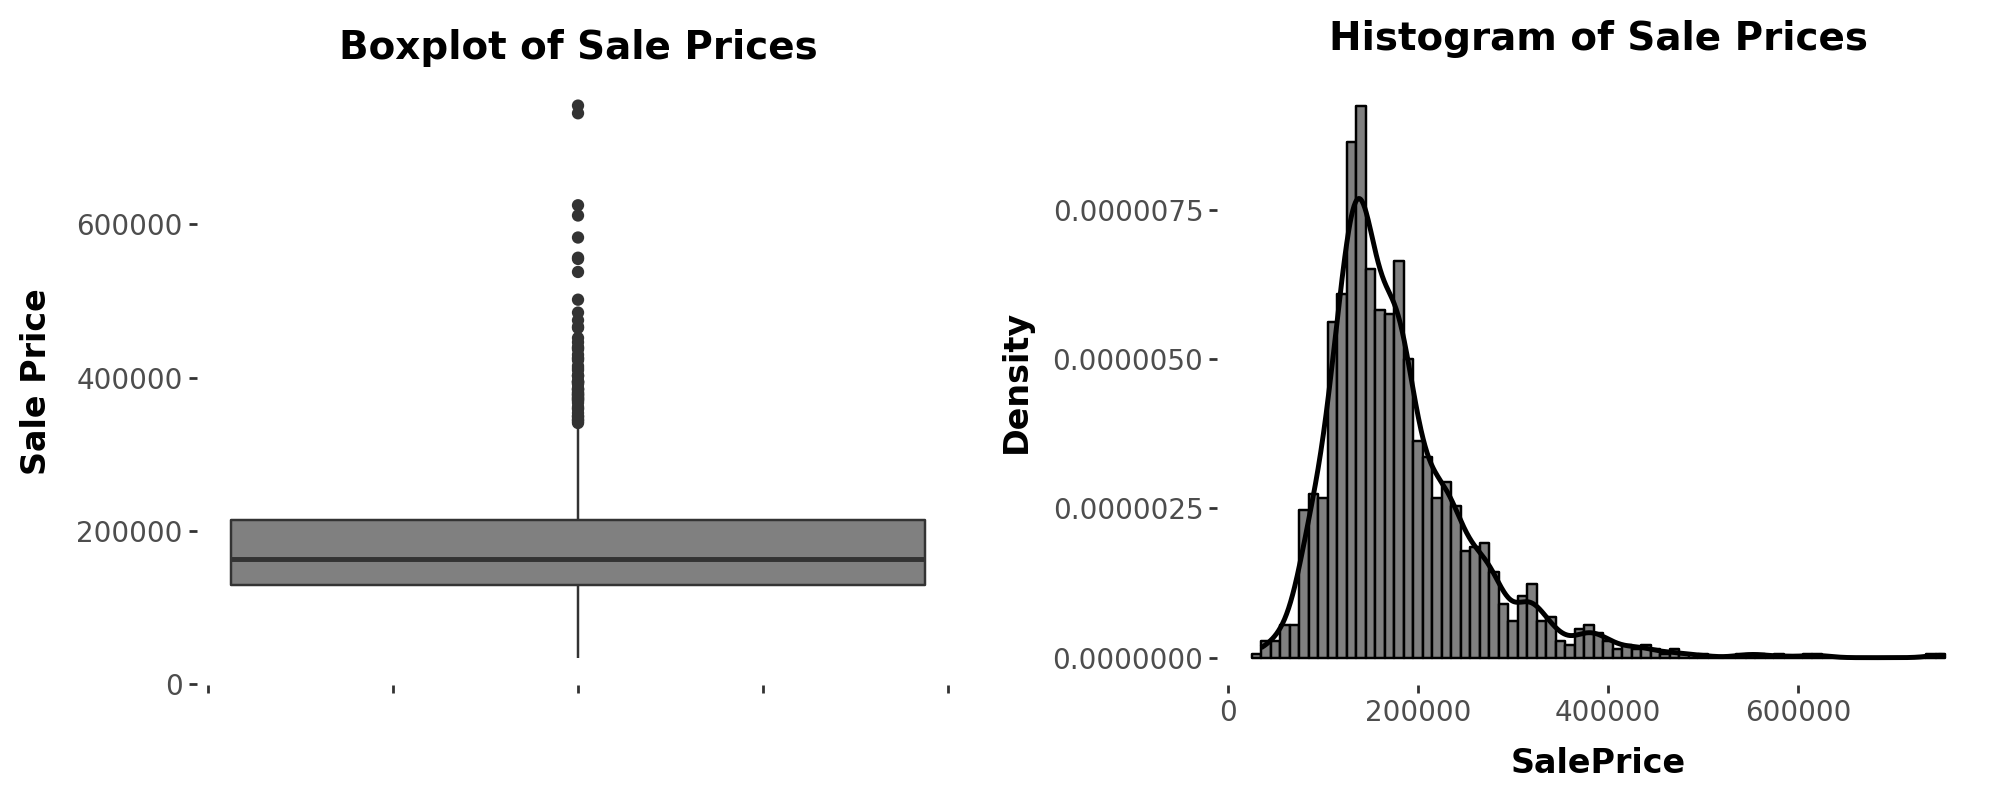

In [7]:
from plotnine import *

# Report theme for all plots 
report_theme = theme(panel_background=element_blank(),
                     panel_grid=element_blank(),
                     axis_title=element_text(size=12, weight='bold'),
                     axis_text=element_text(size=10),
                     plot_title=element_text(size=14, weight='bold', ha='center'))

# Create a histogram of the target variable 'SalePrice'
saleprice_hist = ggplot(train_data, aes(x='SalePrice')) + \
    geom_histogram(aes(y=after_stat("density")), fill='grey', binwidth=10000, color='black') + \
    geom_density(size = 1) + \
    report_theme +  theme(figure_size=(10, 4)) + \
    labs(title='Histogram of Sale Prices', x='SalePrice', y='Density')

# Create a box plot of the target variable 'SalePrice'
saleprice_boxplot = ggplot(train_data, aes(y='SalePrice')) + \
    geom_boxplot(fill = 'grey') + \
    labs(title='Boxplot of Sale Prices', y='Sale Price') \
    + report_theme + theme(axis_text_x= element_blank())

(saleprice_boxplot | saleprice_hist) 

The sales price of the houses has a mean of approximately 181,000 dollars, a median of 163,000 dollars, and a standard deviation of 79,442.5 dollars. The minimum sale price is 34,900 dollars, while the maximum sale price is 755,000 dollars. As we can see from the plot, the distribution of sale prices is right-skewed, with a long tail on the right side. This indicates that there are some houses with very high sale prices that are pulling the mean to the right. The median is lower than the mean, which also suggests that the distribution is skewed.

## Independent Variables 

Let's now explore the independent variables in the dataset. We will look at the summary statistics and visualizations for some of the key features. 

### Size & Space 
The size and space of the house can be measured by features such as GrLivArea, TotalBsmtSF, LotArea, GarageCars. Let's look at the summary statistics for these features.

In [52]:
size_space_features = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'GarageCars']

train_data[size_space_features] \
    .rename(columns={'GrLivArea': 'Above Ground Living Area', 'TotalBsmtSF': 'Total Basement Square Feet', 'LotArea': 'Lot Area', 'GarageCars': 'Garage Capacity'}) \
    .describe().T

,count,mean,std,min,25%,50%,75%,max
Above Ground Living Area,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
Total Basement Square Feet,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0
Lot Area,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
Garage Capacity,1460.0,1.767123,0.747315,0.0,1.00,2.0,2.00,4.0


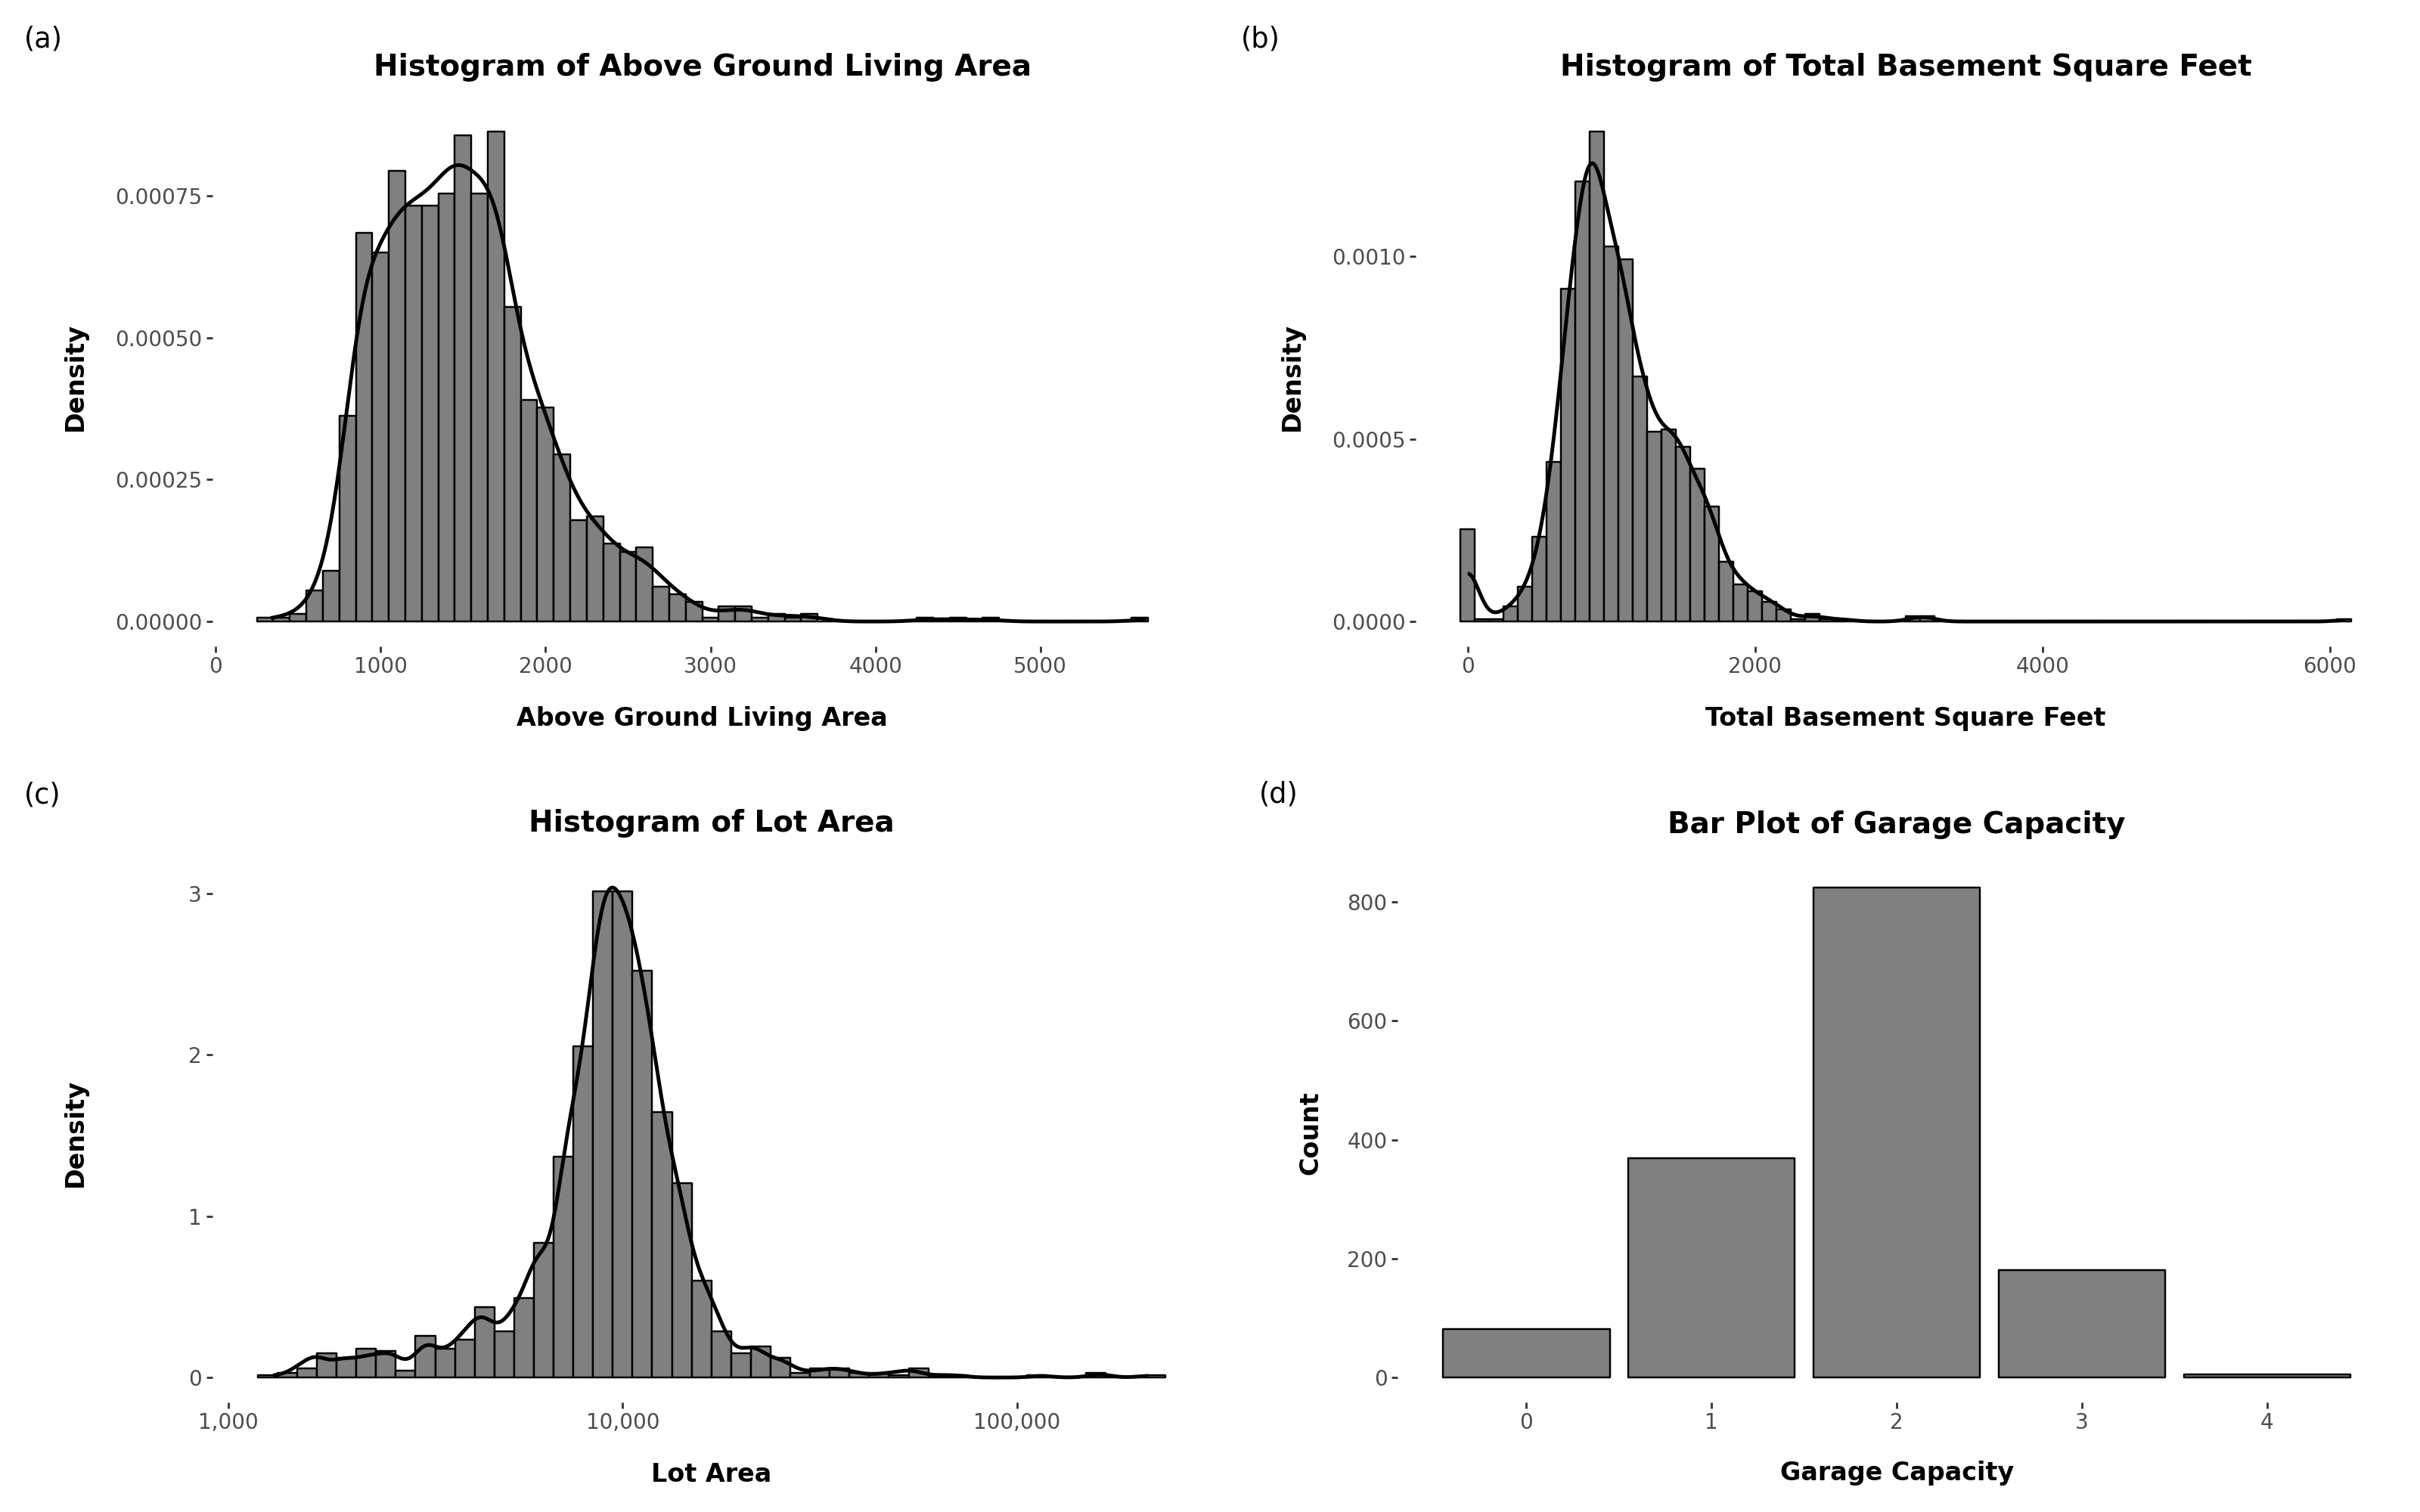

In [53]:
from mizani.formatters import comma_format

living_area_hist = ggplot(train_data, aes(x='GrLivArea')) + \
    geom_histogram(aes(y=after_stat("density")), fill='grey', binwidth=100, color='black') + \
    geom_density(size = 1) + \
    report_theme + theme(figure_size=(10, 6)) + \
    labs(title='Histogram of Above Ground Living Area', x='Above Ground Living Area', y='Density', tag='(a)')

basement_hist = ggplot(train_data, aes(x='TotalBsmtSF')) + \
    geom_histogram(aes(y=after_stat("density")), fill='grey', color='black', binwidth=100) + \
    geom_density(size = 1) + \
    report_theme + theme(figure_size=(10, 6)) + \
    labs(title='Histogram of Total Basement Square Feet', x='Total Basement Square Feet', y='Density' , tag='(b)')

lotarea_hist = ggplot(train_data, aes(x='LotArea')) + \
    geom_histogram(aes(y=after_stat("density")), fill='grey', color='black', binwidth=0.05) + \
    geom_density(size = 1) + \
    scale_x_log10(labels=comma_format()) + \
    report_theme + theme(figure_size=(10, 6)) + \
    labs(title='Histogram of Lot Area', x='Lot Area', y='Density', tag='(c)')

garage_barplot = ggplot(train_data, aes(x='GarageCars')) + \
    geom_bar(fill='grey', color='black') + \
    report_theme + theme(figure_size=(10, 6)) + \
    labs(title='Bar Plot of Garage Capacity', x='Garage Capacity', y='Count', tag='(d)')

(living_area_hist | basement_hist) / (lotarea_hist | garage_barplot) + theme(figure_size=(16, 10))


As we can see from the summary statistics, the average above ground living area (GrLivArea) is approximately 1500 square feet, with a standard deviation of 525. The total basement square footage (TotalBsmtSF) has an average of around 1057 square feet, with a standard deviation of 438. The lot area (LotArea) has a wide range, with an average of 10,000 square feet and a standard deviation of 8,000. The garage capacity (GarageCars) has an average of 0.8 cars, with a standard deviation of 0.9 cars. From the plots, we can see that the above ground living area, the total basement square footage and the lot area have a right-skewed distribution. The most common garage capacity is 2, while a small number of houses do not have a garage at all.

#### Quality & Condition
The quality and condition of the house can be measured by features such as OverallQual, OverallCond, KitchenQual.

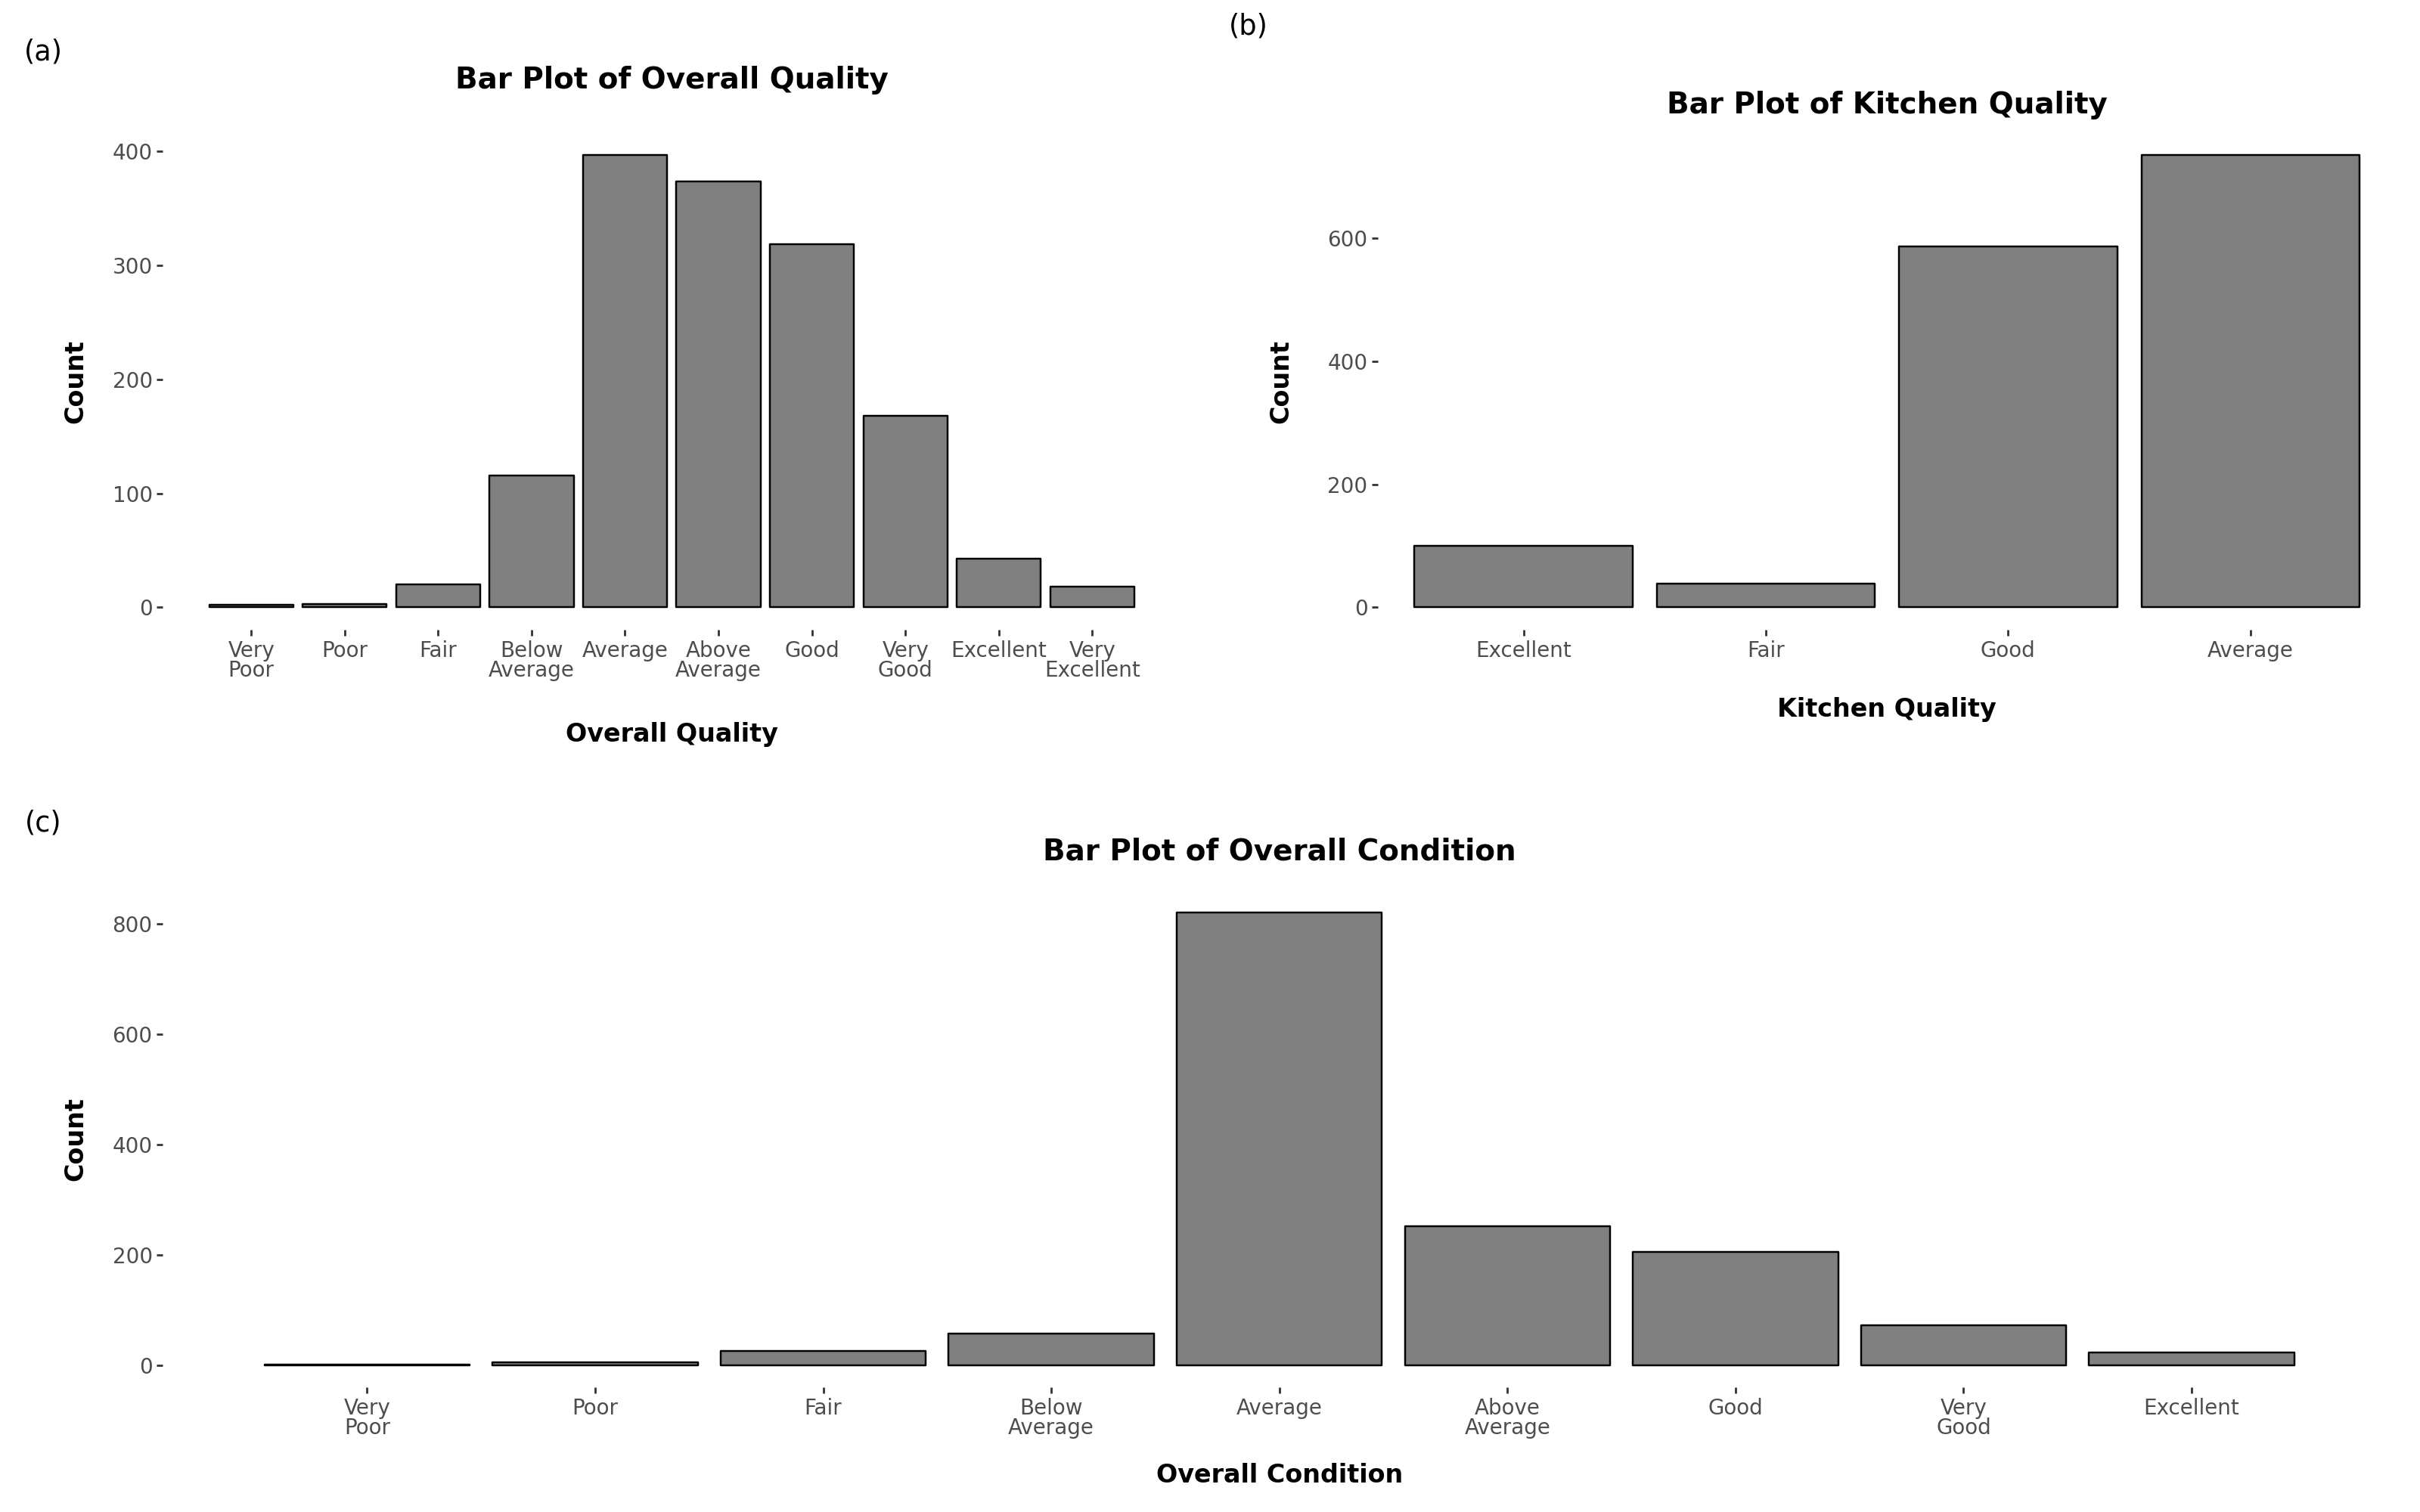

In [54]:
overall_quality_bar = ggplot(train_data, aes(x='OverallQual')) + \
    geom_bar(fill='grey', color='black') + \
    scale_x_continuous(breaks=range(1, 11), labels= {10: 'Very\nExcellent', 9: 'Excellent', 8: 'Very\nGood', 7: 'Good', 6: 'Above\nAverage', 5: 'Average', 4: 'Below\nAverage', 3: 'Fair', 2: 'Poor', 1: 'Very\nPoor'}) + \
    report_theme + theme(figure_size=(15, 6)) + \
    labs(title='Bar Plot of Overall Quality', x='Overall Quality', y='Count', tag='(a)')


overall_condition_bar = ggplot(train_data, aes(x='OverallCond')) + \
    geom_bar(fill='grey', color='black') + \
    scale_x_continuous(breaks=range(1, 11), labels= {10: 'Very\nExcellent', 9: 'Excellent', 8: 'Very\nGood', 7: 'Good', 6: 'Above\nAverage', 5: 'Average', 4: 'Below\nAverage', 3: 'Fair', 2: 'Poor', 1: 'Very\nPoor'}) + \
    report_theme + theme(figure_size=(10, 6)) + \
    labs(title='Bar Plot of Overall Condition', x='Overall Condition', y='Count', tag='(c)')

kitchen_quality_bar = ggplot(train_data, aes(x='KitchenQual')) + \
    geom_bar(fill='grey', color='black') + \
    scale_x_discrete(labels= {'Ex': 'Excellent', 'Gd': 'Good', 'TA': 'Average', 'Fa': 'Fair', 'Po': 'Poor'}) + \
    report_theme + theme(figure_size=(5, 6)) + \
    labs(title='Bar Plot of Kitchen Quality', x='Kitchen Quality', y='Count', tag='(b)')

(overall_quality_bar |kitchen_quality_bar) / overall_condition_bar + theme(figure_size=(16, 10))

Most houses have an overall quality of average (OverallQual = 5) or above average (OverallQual = 6). The overall condition of the houses is mostly average (OverallCond = 5), with a small number of houses in excellent condition (OverallCond = 9). The kitchen quality is mostly average (KitchenQual = 'TA') or good (KitchenQual = 'Gd'), with a small number of houses having excellent kitchen quality (KitchenQual = 'Ex').

### Age & Time

The age and time-related features of the house can be measured by features such as YearBuilt and YearRemodAdd. Let's look at the summary statistics for these features.

In [55]:
train_data[['YearBuilt', 'YearRemodAdd']].describe().T

,count,mean,std,min,25%,50%,75%,max
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.0,1973.0,2000.0,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.0,1994.0,2004.0,2010.0


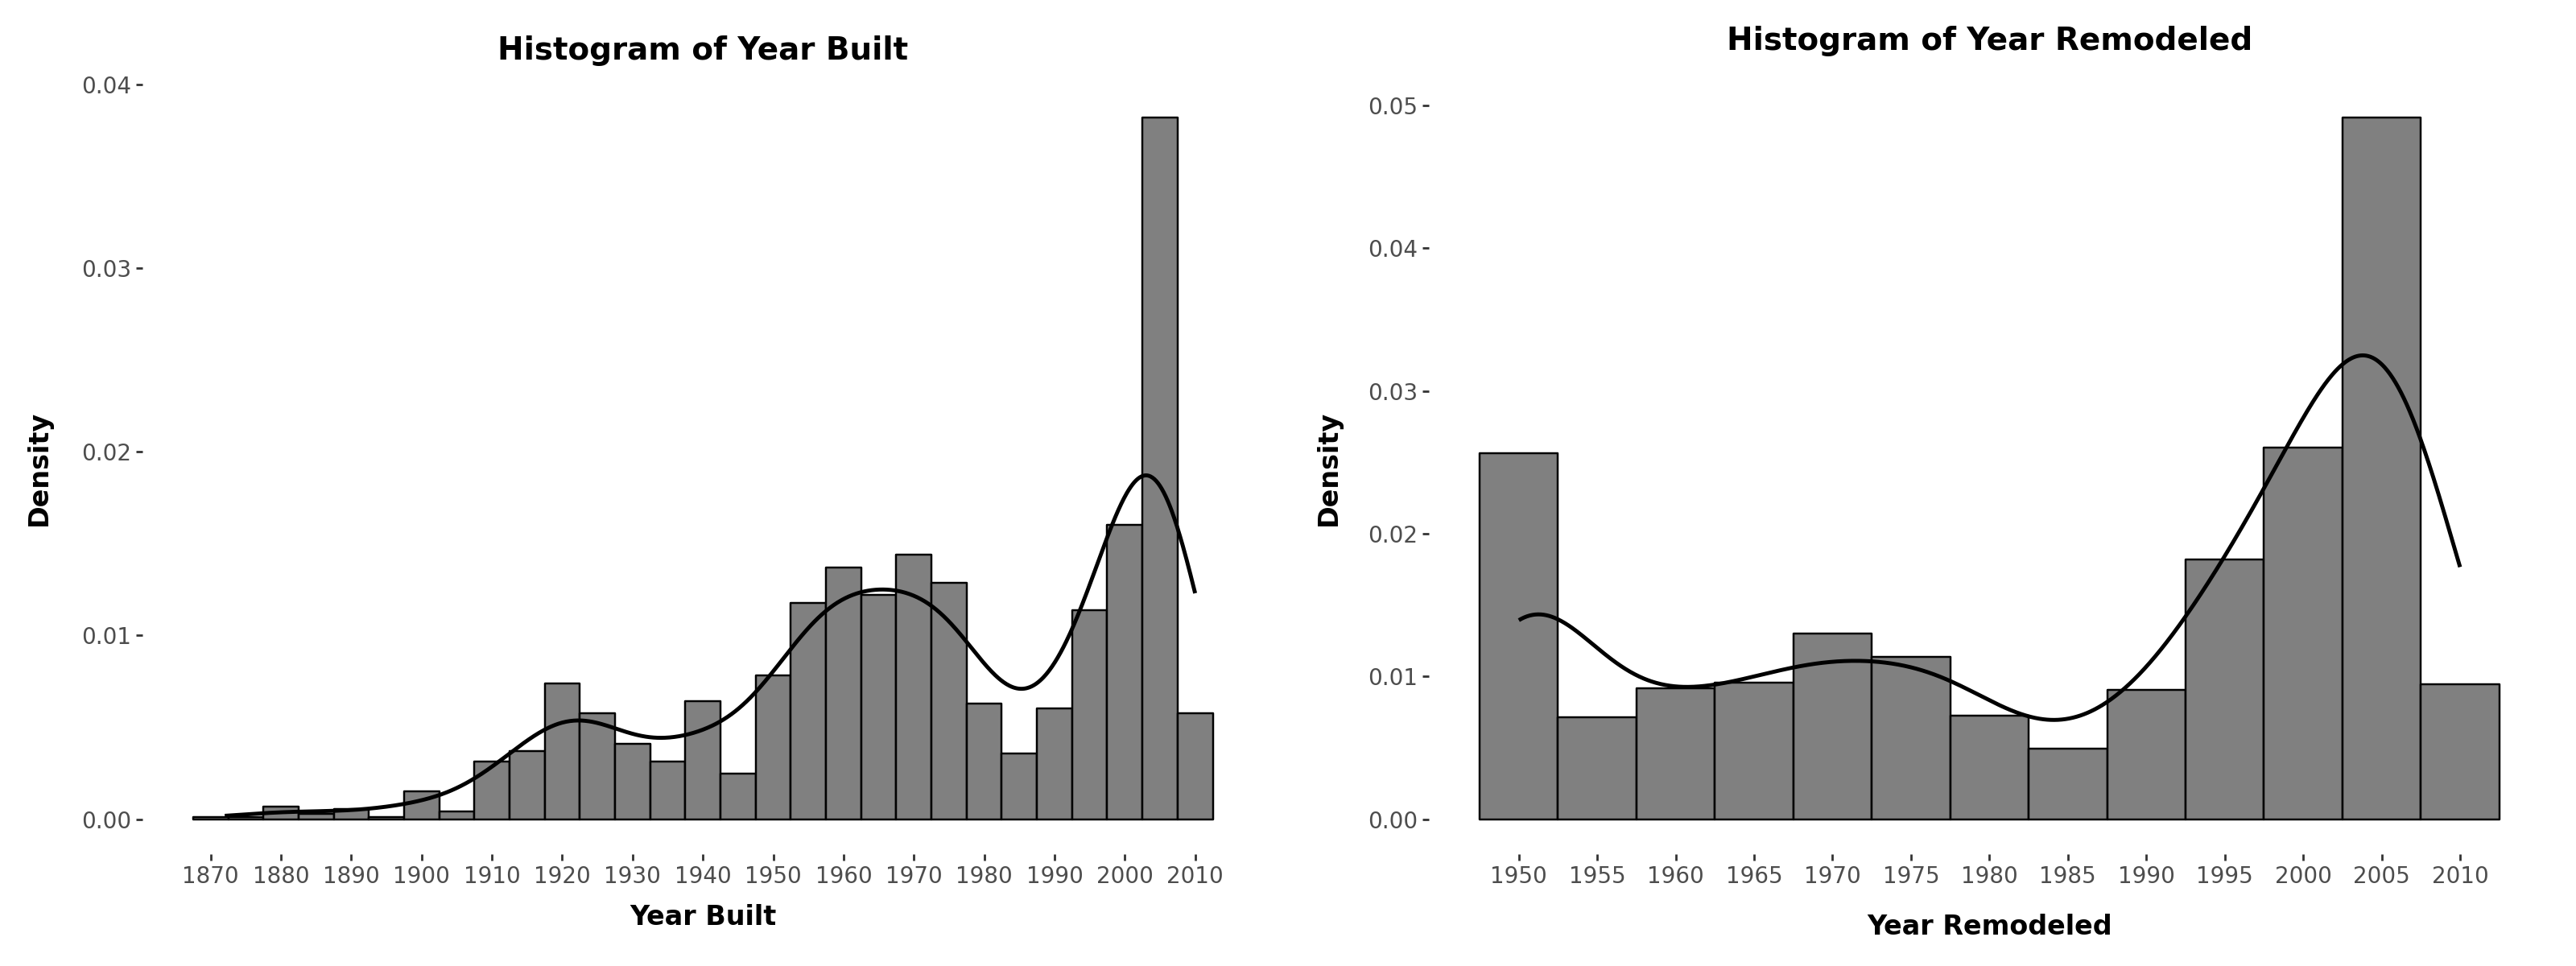

In [56]:
year_built_hist = ggplot(train_data, aes(x='YearBuilt')) + \
    geom_histogram(aes(y=after_stat("density")), fill='grey', color='black', binwidth=5) + \
    geom_density(size = 1) + \
    report_theme + theme(figure_size=(10, 6)) + \
    scale_x_continuous(breaks=range(1870, 2011, 10)) + \
    labs(title='Histogram of Year Built', x='Year Built', y='Density')

year_remod_hist = ggplot(train_data, aes(x='YearRemodAdd')) + \
    geom_histogram(aes(y=after_stat("density")), fill='grey', color='black', binwidth=5) + \
    geom_density(size = 1) + \
    report_theme + theme(figure_size=(10, 6)) + \
    scale_x_continuous(breaks=range(1950, 2011, 5)) + \
    labs(title='Histogram of Year Remodeled', x='Year Remodeled', y='Density')

year_built_hist | year_remod_hist + theme(figure_size=(16, 6))


The houses in the dataset were built between 1872 and 2010, with an average year built of 1971. The average year of remodeling or addition is 1984, with a range from 1950 to 2010. This indicates that most houses in the dataset are relatively old, with some having been remodeled or added to in more recent years.

#### Location & Property Type

Neighborhood and property type can be measured by features such as Neighborhood and MSZoning. Let's look at the distribution of these features. 

We will map the neighborhood codes to their actual names for better visualization.

In [57]:
neighborhood_labels = {"Blmngtn": "Bloomington Heights",
           "Blueste": "Bluestem",
           "BrDale": "Briardale",
           "BrkSide": "Brookside",
           "ClearCr": "Clear Creek",
           "CollgCr": "College Creek",
           "Crawfor": "Crawford",
           "Edwards": "Edwards",
           "Gilbert": "Gilbert",
           "IDOTRR": "Iowa DOT and Rail Road",
           "MeadowV": "Meadow Village",
           "Mitchel": "Mitchell",
           "NAmes": "North Ames",
           "NoRidge": "Northridge",
           "NPkVill": "Northpark Villa",
           "NridgHt": "Northridge Heights",
           "NWAmes": "Northwest Ames",
           "OldTown": "Old Town",
           "SWISU": "South & West of Iowa State University",
           "Sawyer": "Sawyer",
           "SawyerW": "Sawyer West",
           "Somerst": "Somerset",
           "StoneBr": "Stone Brook",
           "Timber": "Timberland",
           "Veenker": "Veenker"
}

neighborhood_bar = ggplot(train_data, aes(x='Neighborhood')) + \
    geom_bar(fill='grey', color='black') + \
    scale_x_discrete(labels=neighborhood_labels) + \
    report_theme + theme(figure_size=(15, 6), axis_text_x=element_text(angle=45, hjust=1)) + \
    labs(title='Bar Plot of Neighborhood', x='Neighborhood', y='Count')

Next, we will look at the distribution of the MSZoning feature, which indicates the general zoning classification of the property. The most common zoning classification is RL (Residential Low Density), followed by RM (Residential Medium Density) and FV (Floating Village Residential). There are also a small number of properties classified as C (Commercial) and I (Industrial).

In [58]:
mszoning_mapping = {"A": "Agriculture",
                    "C": "Commercial",
                    "FV": "Floating Village Residential",
                    "I": "Industrial",
                    "RH": "Residential High Density",
                    "RL": "Residential Low Density",
                    "RP": "Residential Low Density Park",
                    "RM": "Residential Medium Density"}

mszoning_bar = ggplot(train_data, aes(x='MSZoning')) + \
    geom_bar(fill='grey', color='black') + \
    scale_x_discrete(labels=mszoning_mapping) + \
    report_theme + theme(figure_size=(10, 6), axis_text_x=element_text(angle=45, hjust=1)) + \
    labs(title='Bar Plot of Zones', x='Zones', y='Count')


Finally, we will look at the distribution of the Neighborhood feature, which indicates the physical locations within Ames city limits. The most common neighborhoods in the dataset are NAmes, CollgCr, OldTown, Edwards and Somerville. There are also a small number of houses located in other neighborhoods such as BrkSide, Sawyer and NWAmes.

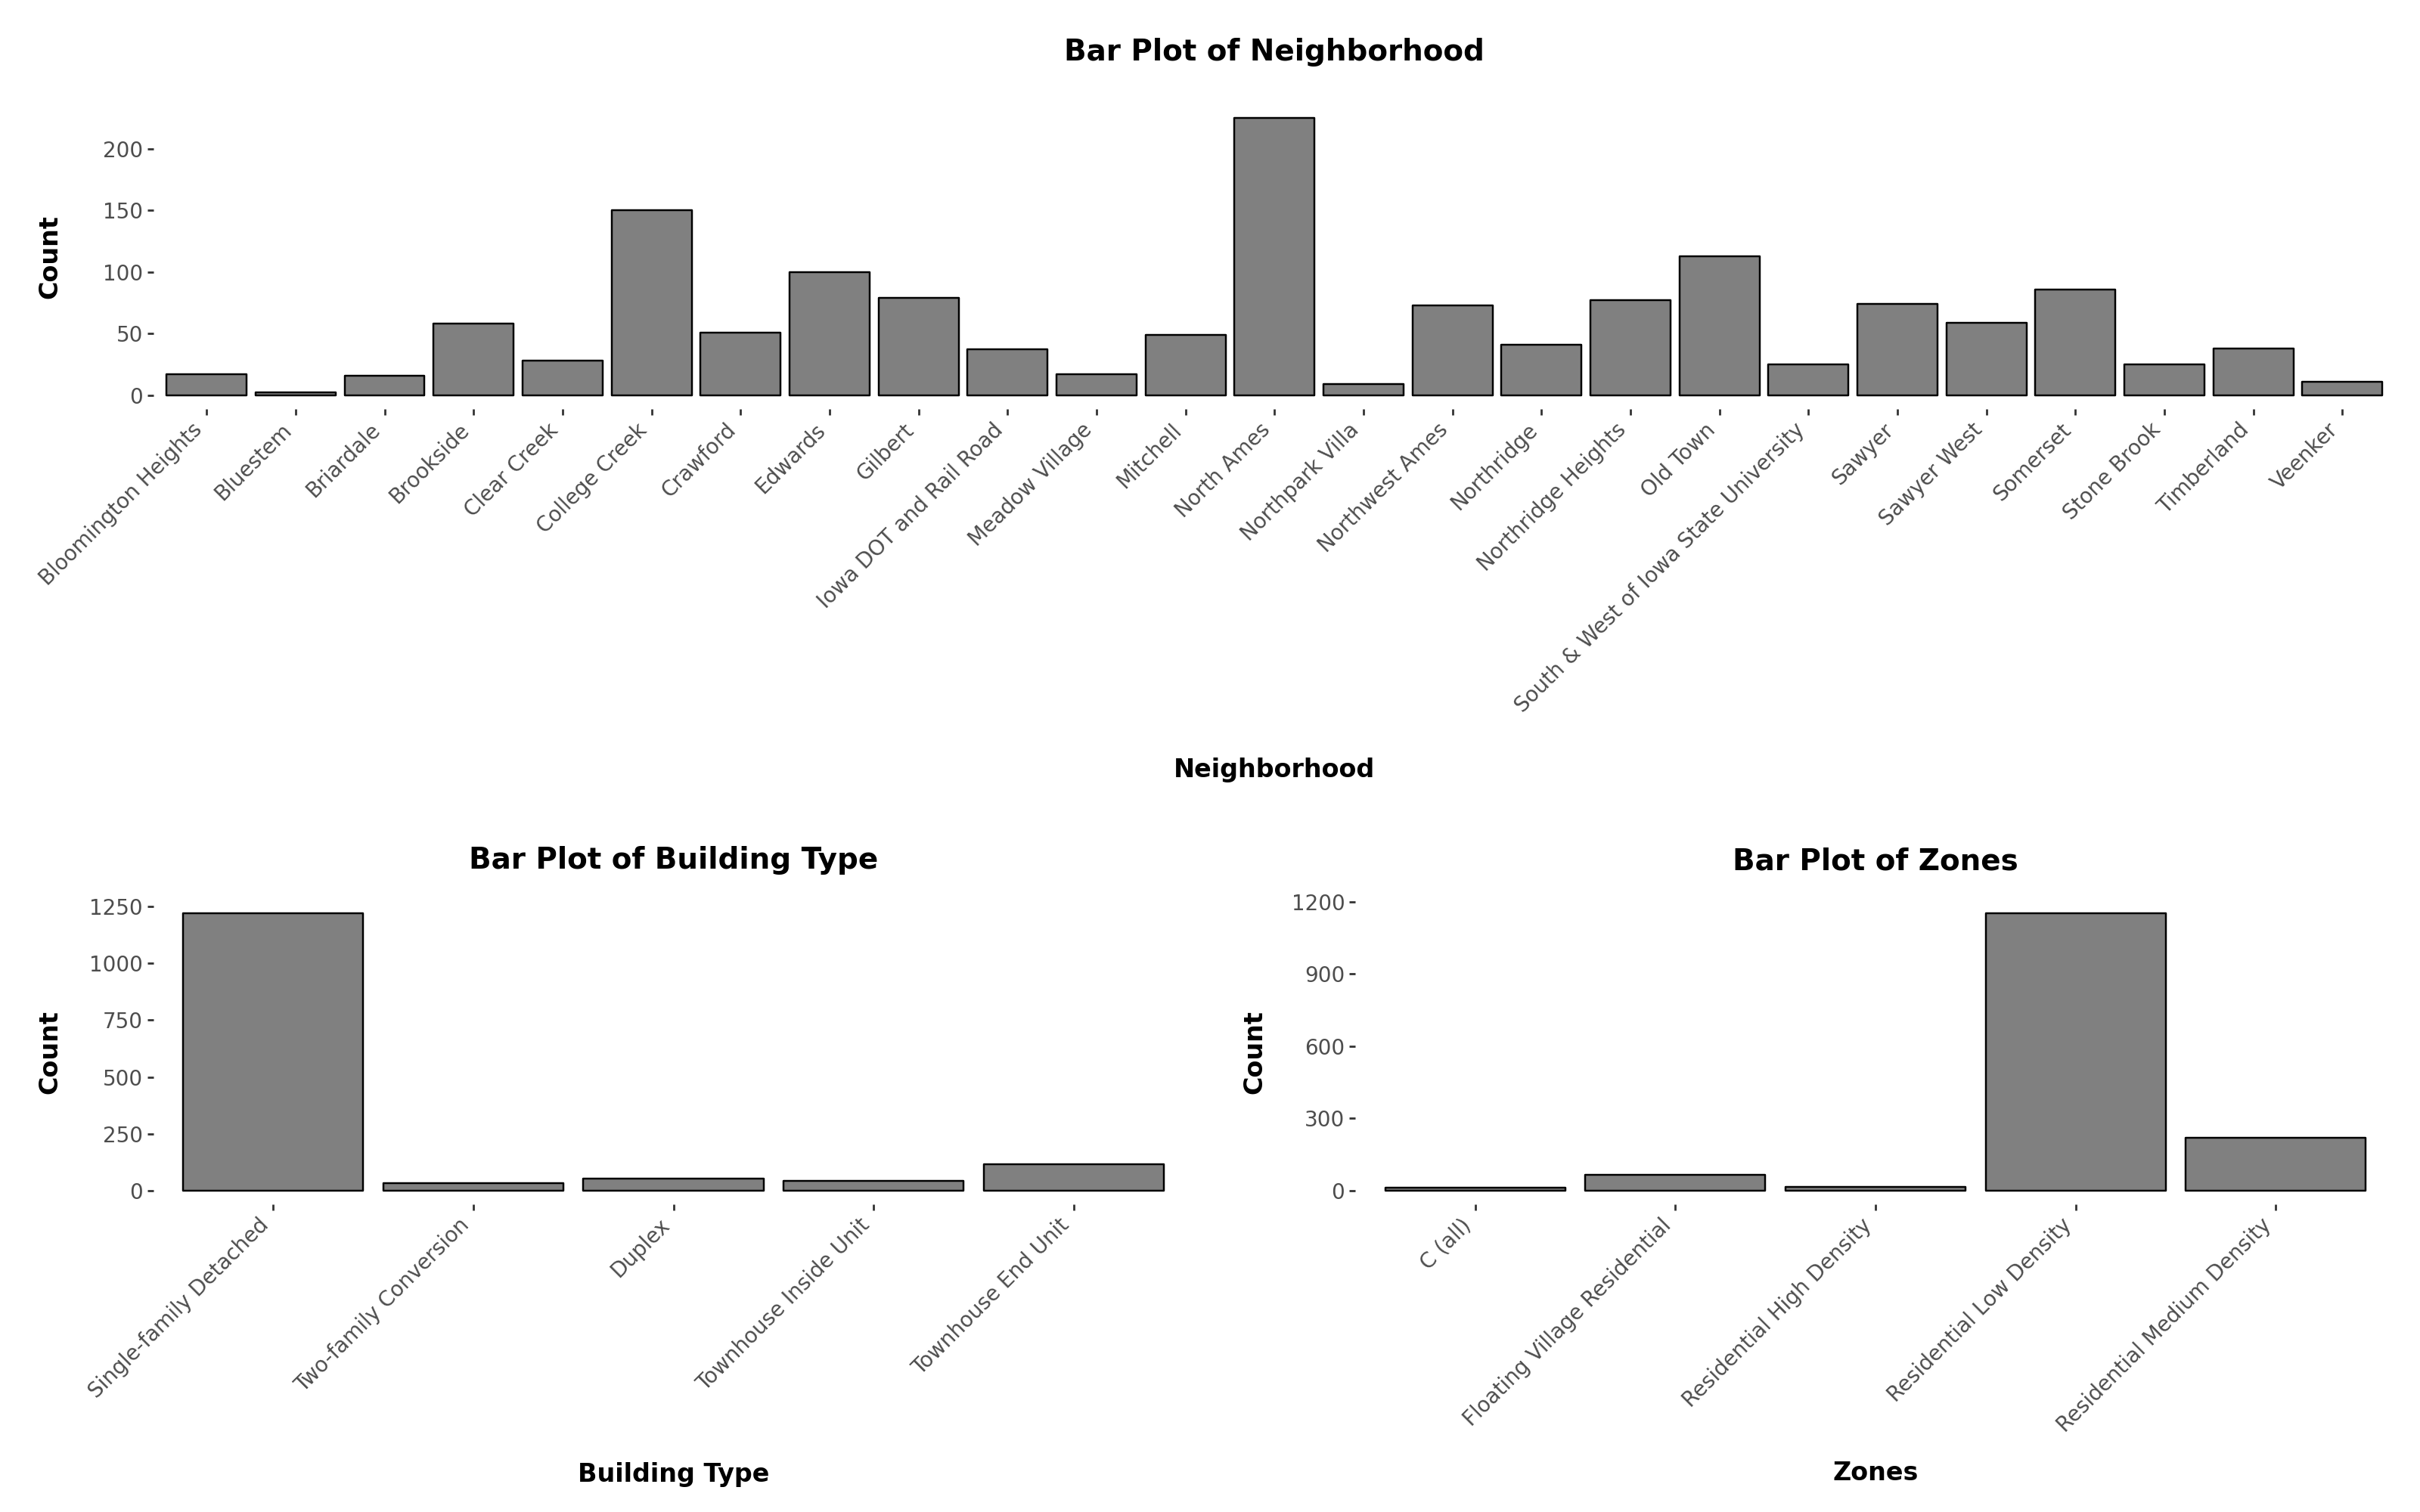

In [59]:
bldgtype_mappings = {"1Fam": "Single-family Detached",
                     "2fmCon": "Two-family Conversion",
                     "Duplx": "Duplex",
                     "TwnhsE": "Townhouse End Unit",
                     "Twnhs": "Townhouse Inside Unit"}

bldgtype_bar = ggplot(train_data, aes(x='BldgType')) + \
    geom_bar(fill='grey', color='black') + \
    scale_x_discrete(labels=bldgtype_mappings) + \
    report_theme + theme(figure_size=(10, 6), axis_text_x=element_text(angle=45, hjust=1)) + \
    labs(title='Bar Plot of Building Type', x='Building Type', y='Count') 
  
(neighborhood_bar / ( bldgtype_bar | mszoning_bar) ) + theme(figure_size=(16, 10))

From the plots, we can see that the most common zoning classification is RL (Residential Low Density), followed by RM (Residential Medium Density) and FV (Floating Village Residential). There are also a small number of properties classified as C (Commercial) and I (Industrial). The most common neighborhoods in the dataset are NAmes, CollgCr, OldTown, Edwards and Somerville. There are also a small number of houses located in other neighborhoods such as BrkSide, Sawyer and NWAmes. The types of the houses in the dataset are mostly single-family homes (1Fam), with a small number of duplexes (Duplex) and townhouses (TwnhsE).

## Bivariate Exploratory Data Analysis (EDA)

In this section, we will perform bivariate EDA, which focuses on analyzing the relationship between two variables. We will look at the relationship between the target variable, SalePrice, and some of the key predictor variables such as GrLivArea, TotalBsmtSF, LotArea, GarageCars, OverallQual, OverallCond, KitchenQual, YearBuilt, YearRemodAdd, Neighborhood and MSZoning. We will use various visualization techniques such as scatter plots and box plots to explore the relationships between these variables. This analysis will help us understand how the predictor variables are related to the target variable and identify any potential patterns or trends in the data.

### Size & Space vs SalePrice

We will start by looking at the relationship between the size and space features (GrLivArea, TotalBsmtSF, LotArea, GarageCars) and the sale price of the houses. 

Let;s start with the correlations of these features with the sale price.

In [60]:
train_data[size_space_features + ['SalePrice']].corr()['SalePrice'] \
    .sort_values(ascending=False) \
    .rename({'GrLivArea': 'Above Ground Living Area', 'TotalBsmtSF': 'Total Basement Square Feet', 'LotArea': 'Lot Area', 'GarageCars': 'Garage Capacity'}) \
    .to_frame('Correlation with SalePrice')

,Correlation with SalePrice
SalePrice,1.000000
Above Ground Living Area,0.708624
Garage Capacity,0.640409
Total Basement Square Feet,0.613581
Lot Area,0.263843


The price of the houses is most strongly correlated with the above ground living area (GrLivArea) and the total basement square footage (TotalBsmtSF), with correlation coefficients of 0.71 and 0.61 respectively. The lot area (LotArea) has a weaker correlation with the sale price, with a coefficient of 0.26. The garage capacity (GarageCars) has a moderate correlation with the sale price, with a coefficient of 0.64. This suggests that larger houses with more living space and larger garages tend to have higher sale prices, while the size of the lot has a weaker influence on the sale price.

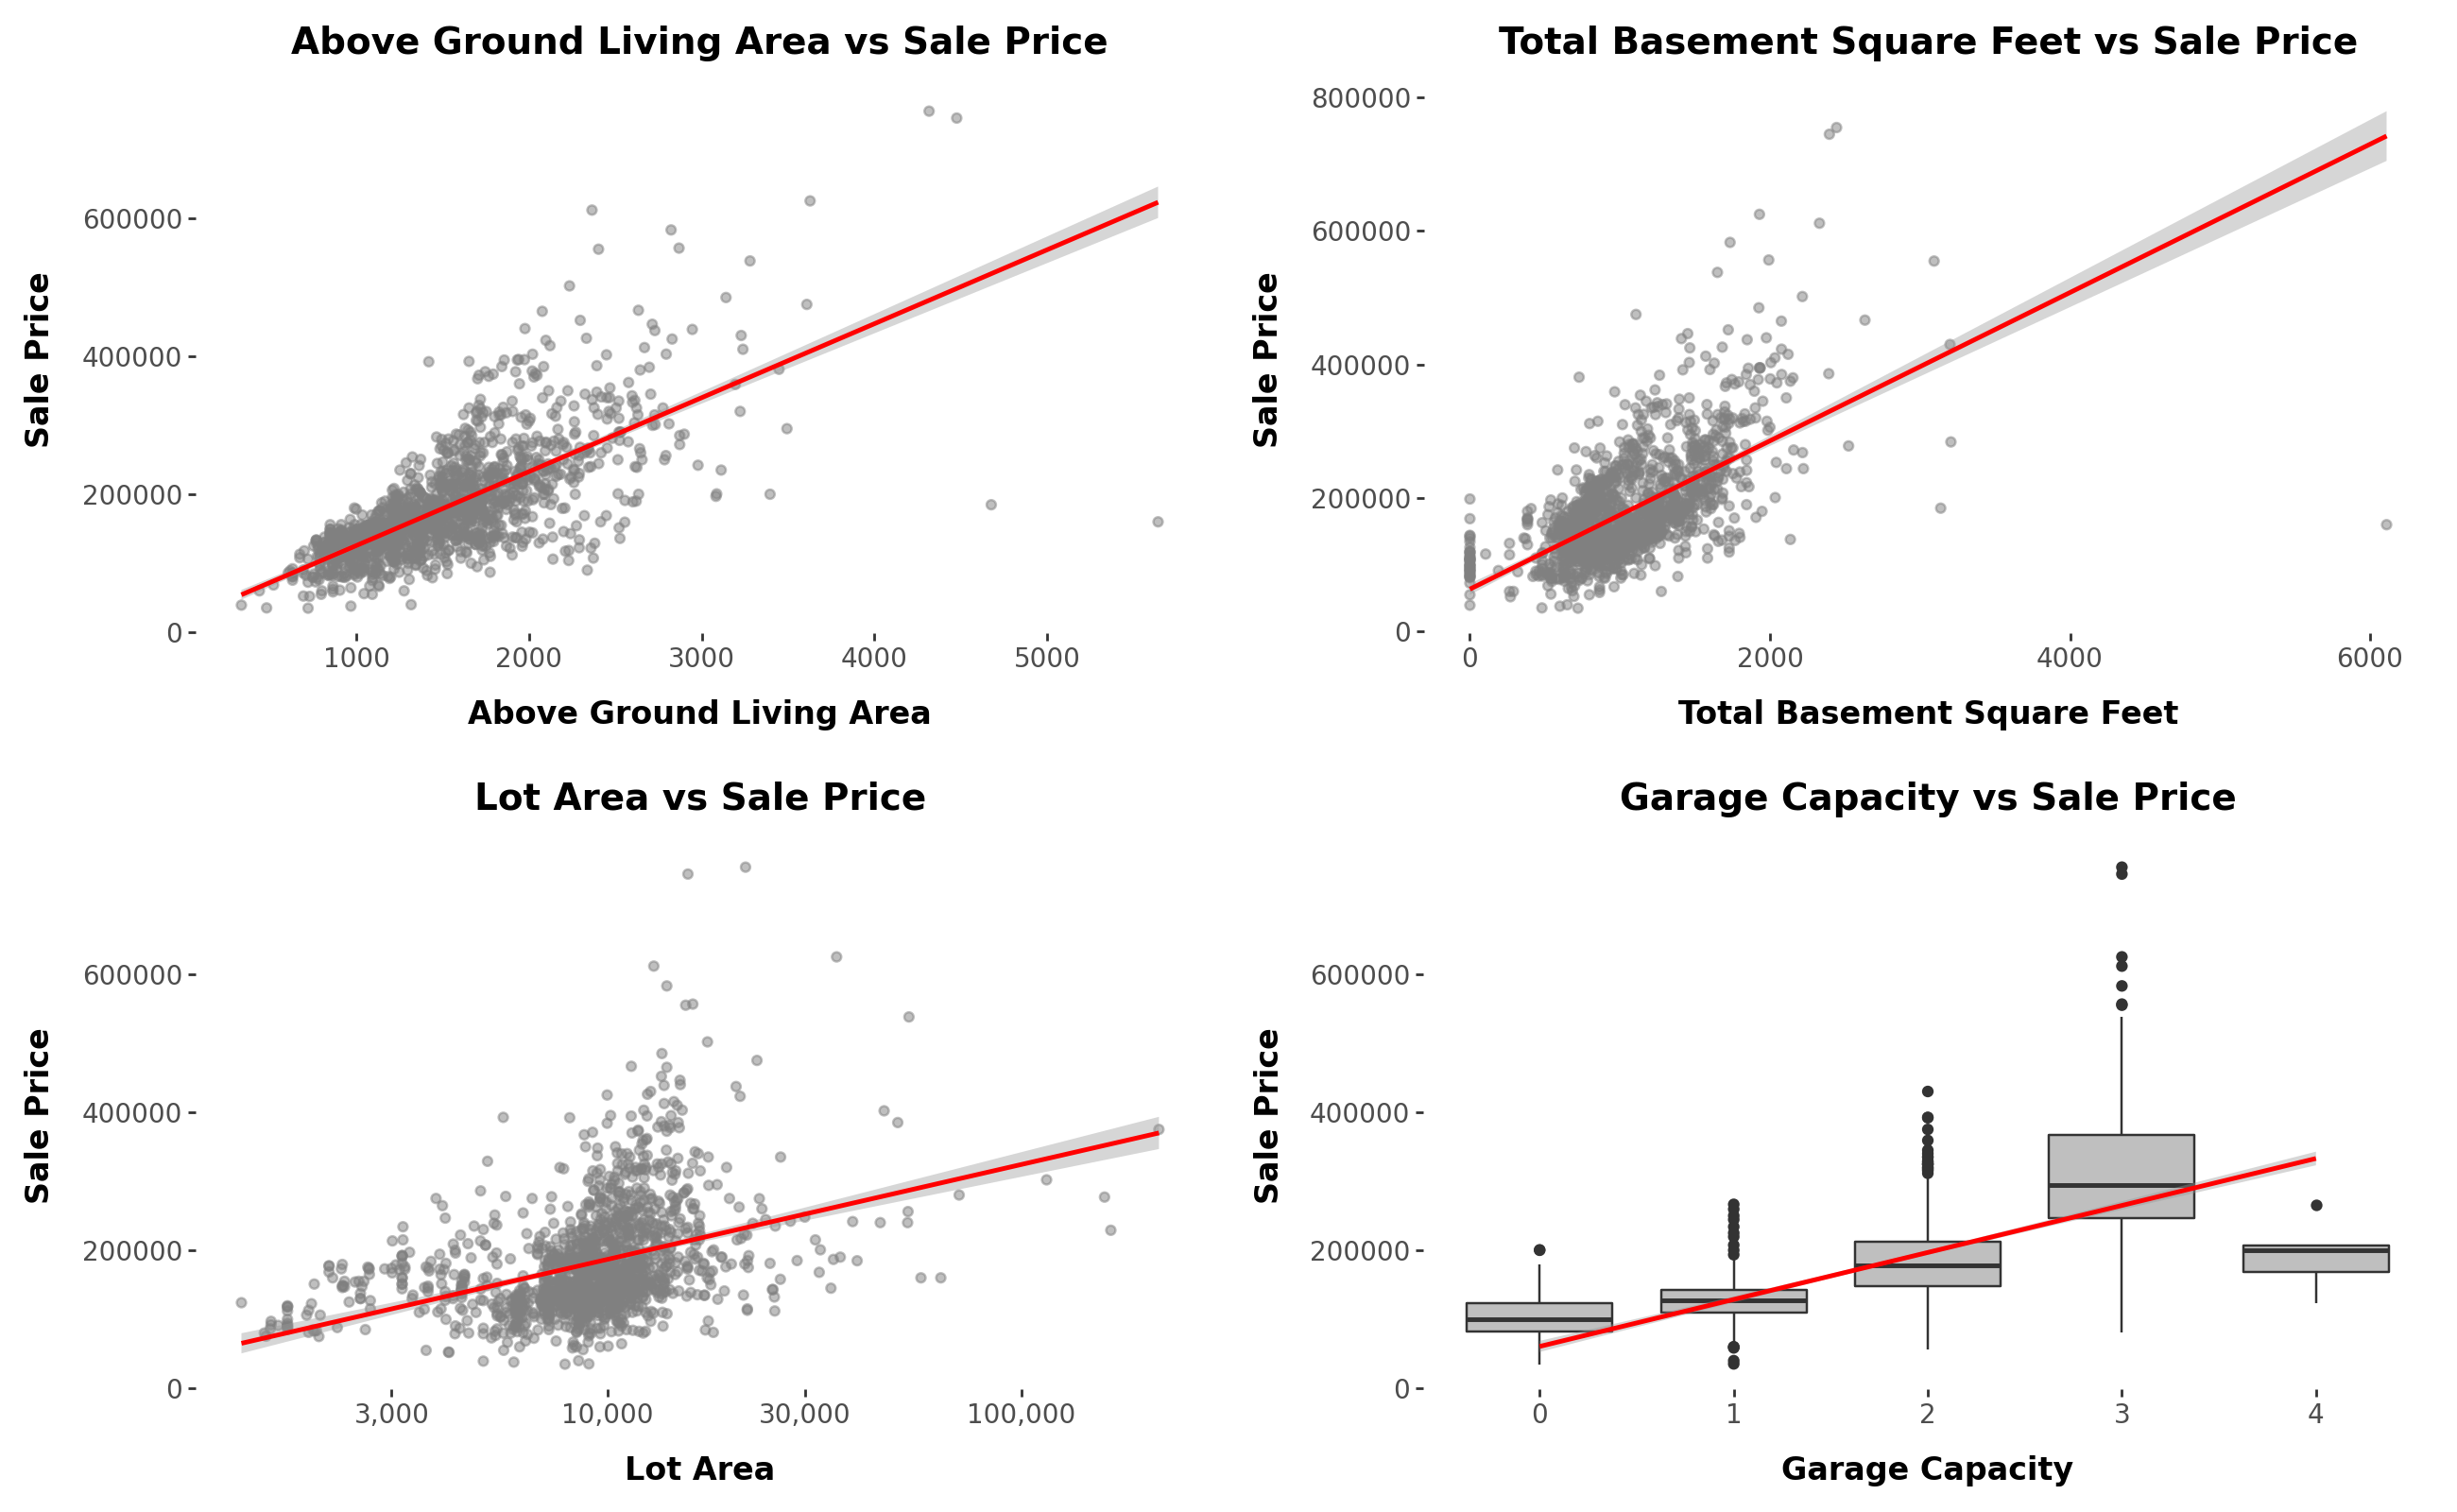

In [63]:
living_area_scatter = ggplot(train_data, aes(x='GrLivArea', y='SalePrice')) + \
    geom_point(color='grey', alpha=0.5) + \
    geom_smooth(method='lm', color='red') + \
    report_theme + theme(figure_size=(10, 6)) + \
    labs(title='Above Ground Living Area vs Sale Price', x='Above Ground Living Area', y='Sale Price')

total_bsmt_scatter = ggplot(train_data, aes(x='TotalBsmtSF', y='SalePrice')) + \
    geom_point(color='grey', alpha=0.5) + \
    geom_smooth(method='lm', color='red') + \
    report_theme + theme(figure_size=(10, 6)) + \
    labs(title='Total Basement Square Feet vs Sale Price', x='Total Basement Square Feet', y='Sale Price')

lotarea_scatter = ggplot(train_data, aes(x='LotArea', y='SalePrice')) + \
    geom_point(color='grey', alpha=0.5) + \
    geom_smooth(method='lm', color='red') + \
    scale_x_log10(labels=comma_format()) + \
    report_theme + theme(figure_size=(10, 6)) + \
    labs(title='Lot Area vs Sale Price', x='Lot Area', y='Sale Price')

garage_box = ggplot(train_data, aes(x='factor(GarageCars)', y='SalePrice')) + \
    geom_boxplot(fill='grey', alpha=0.5) + \
    geom_smooth(aes(group=1), method='lm', color='red') + \
    report_theme + theme(figure_size=(10, 6)) + \
    labs(title='Garage Capacity vs Sale Price', x='Garage Capacity', y='Sale Price')

(living_area_scatter | total_bsmt_scatter) / (lotarea_scatter | garage_box) + theme(figure_size=(13, 8))

The Living area above the ground (GrLivArea) has a strong positive correlation with the sale price, indicating that as the living area increases, the sale price tends to increase as well. The total basement square footage (TotalBsmtSF) also has a strong positive correlation with the sale price, suggesting that houses with larger basements tend to have higher sale prices. The garage capacity (GarageCars) has a moderate positive correlation with the sale price, indicating that houses with larger garages tend to have higher sale prices(0 to 3 garage spaces), however the price of the houses is not larger when the garage capacity is 4. The lot area (LotArea) has a weaker positive correlation with the sale price, suggesting that while larger lots may contribute to higher sale prices, they are not as strong of a predictor as the living area and basement square footage. Overall, these correlations suggest that the size and space features of the house play an important role in determining the sale price, with larger houses and those with more living space and larger garages tending to have higher sale prices.

### Quality & Condition vs SalePrice

Next, we will look at the relationship between the quality and condition features (OverallQual, OverallCond, KitchenQual) and the sale price of the houses.

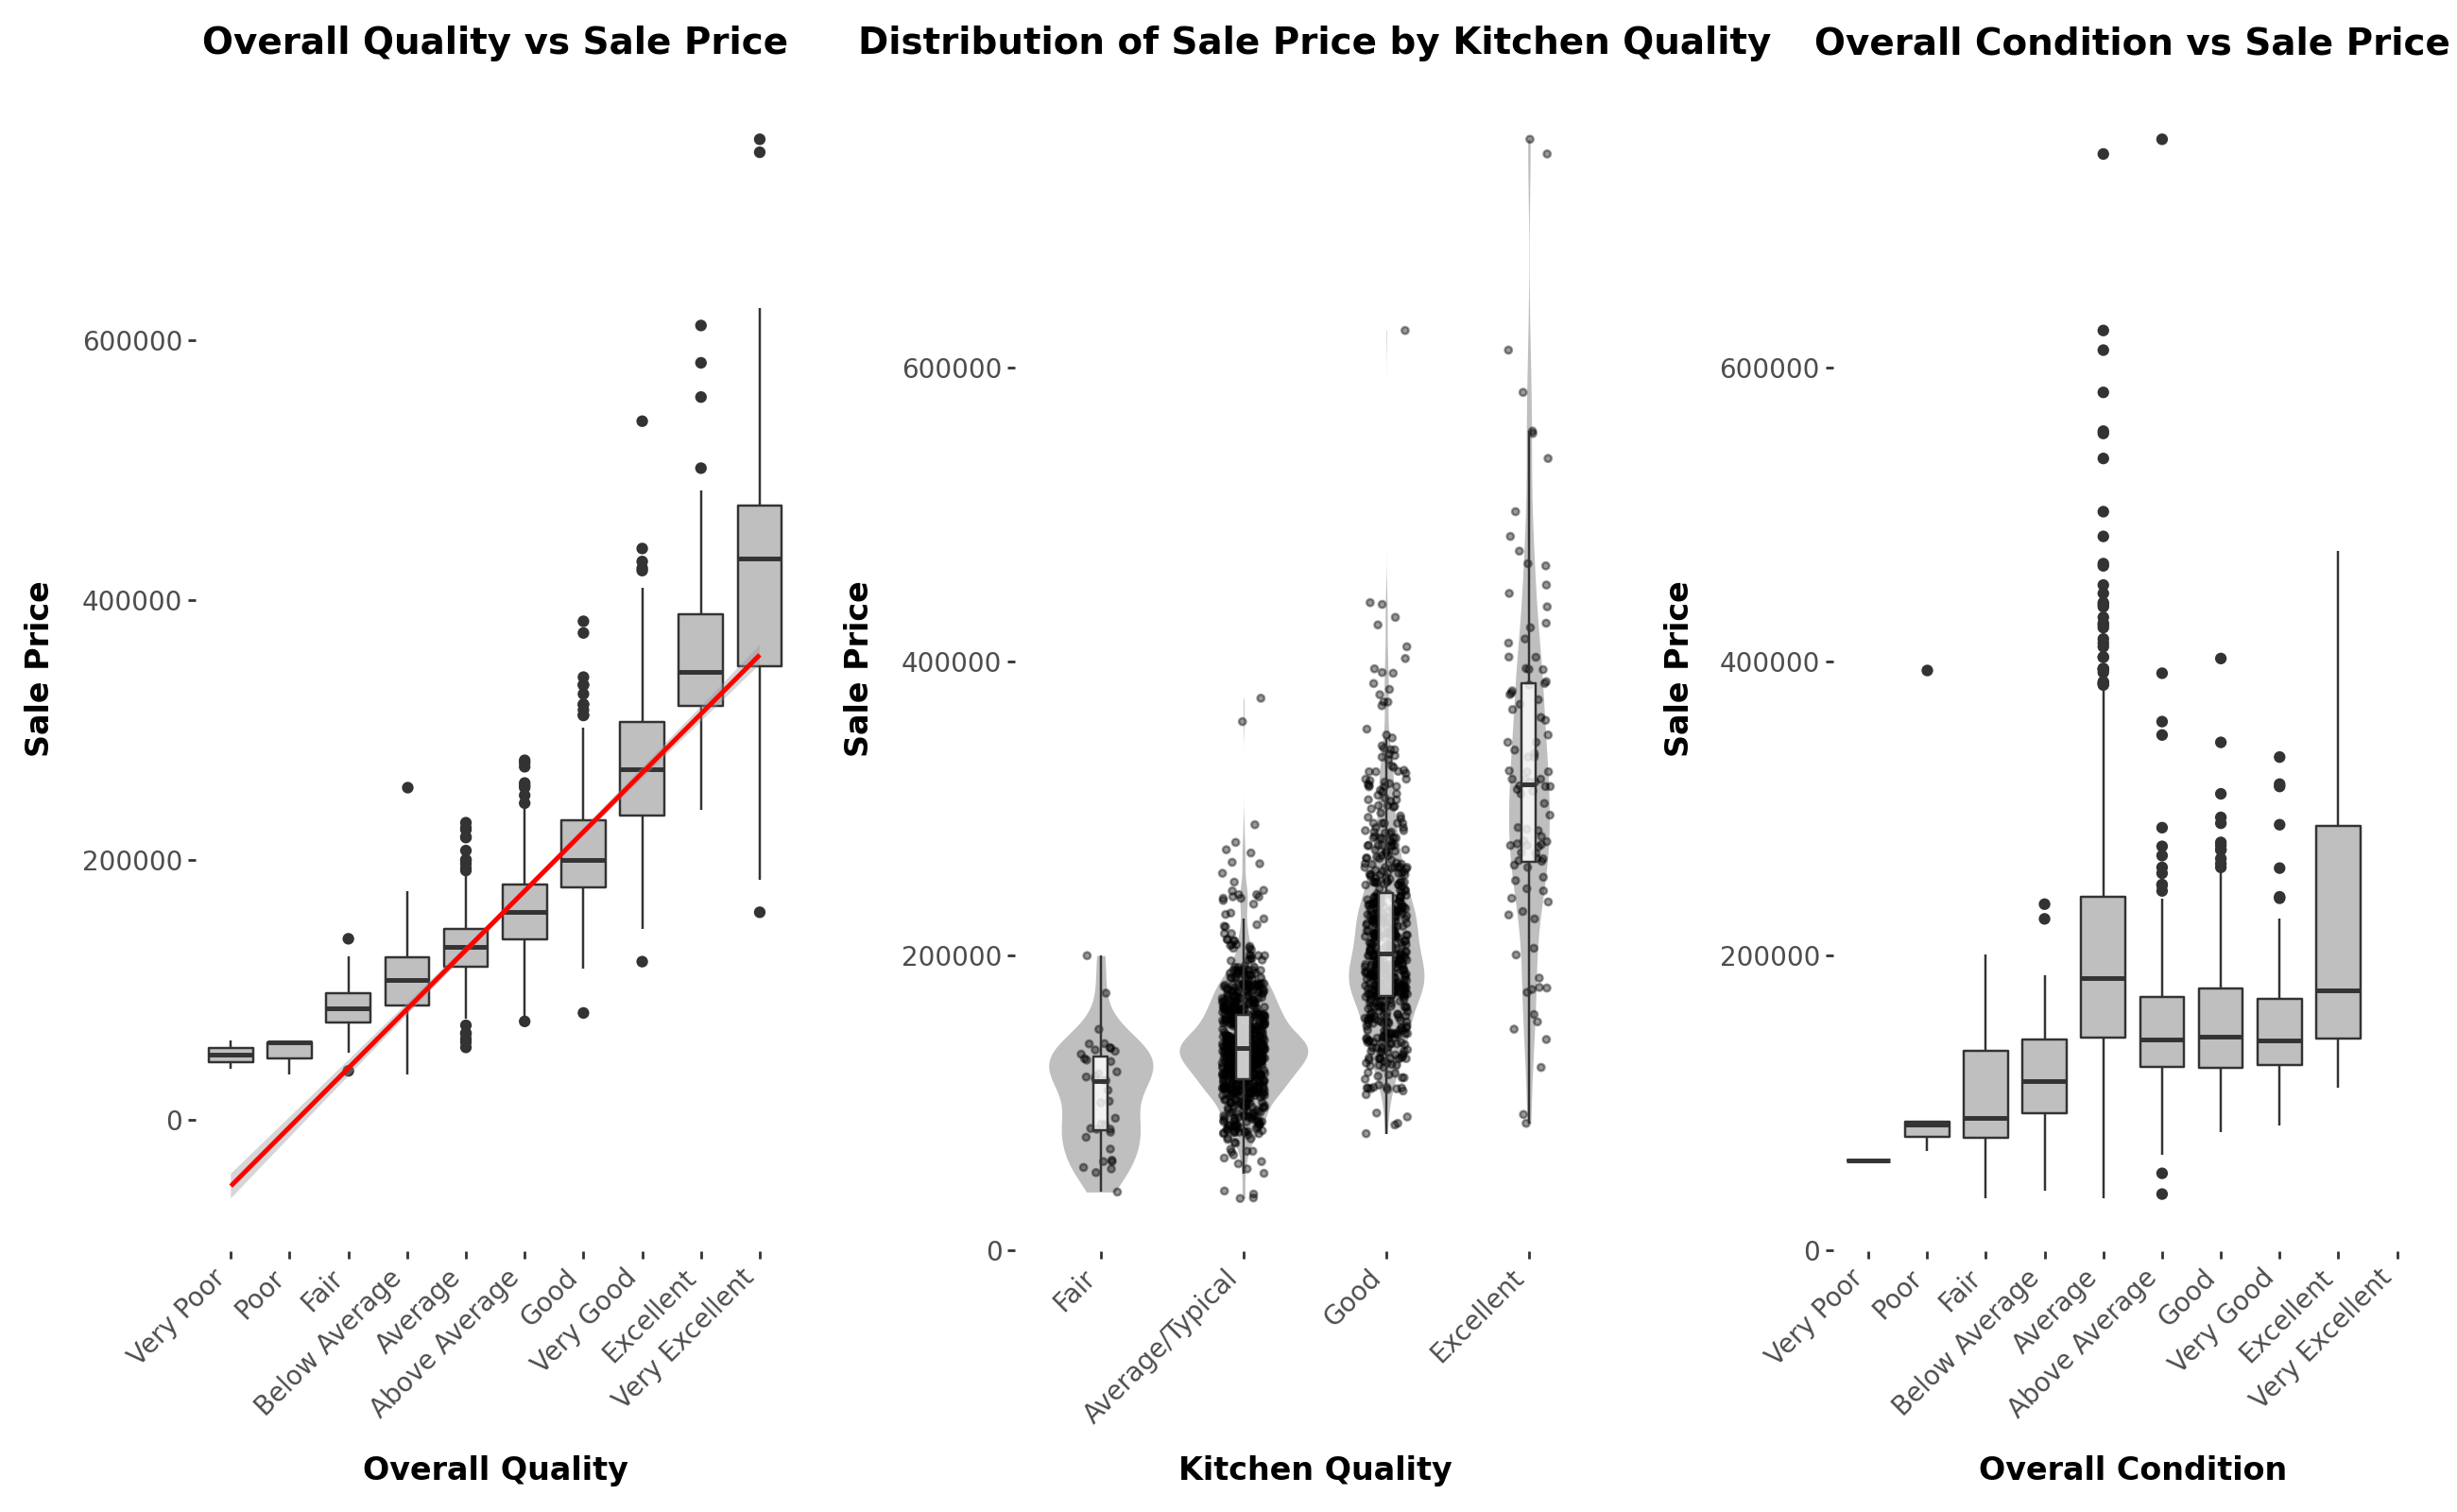

In [86]:
overall_quality_boxplot = ggplot(train_data, aes(x='factor(OverallQual)', y='SalePrice')) + \
    geom_boxplot(fill='grey', alpha=0.5) + \
    geom_smooth(aes(group=1), method='lm', color='red') + \
    report_theme + theme(figure_size=(10, 6), axis_text_x=element_text(angle=45, hjust=1)) + \
    scale_x_discrete(limits=range(1, 11), labels= {10: 'Very Excellent', 9: 'Excellent', 8: 'Very Good', 7: 'Good', 6: 'Above Average', 5: 'Average', 4: 'Below Average', 3: 'Fair', 2:  'Poor', 1: 'Very Poor'}) + \
    labs(title='Overall Quality vs Sale Price', x='Overall Quality', y='Sale Price')

quality_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

train_data['KitchenQual'] = pd.Categorical(
    train_data['KitchenQual'], 
    categories=quality_order, 
    ordered=True
)

kitchen_violin = ggplot(train_data, aes(x='KitchenQual', y='SalePrice')) + \
    geom_violin(fill='grey', alpha=0.5, color='none') + \
    geom_jitter(width=0.15, alpha=0.4, size=1, color='black') + \
    geom_boxplot(width=0.1, fill='white', alpha=0.8, outlier_shape='') + \
    scale_x_discrete(labels={'Po': 'Poor', 'Fa': 'Fair', 'TA': 'Average/Typical', 'Gd': 'Good', 'Ex': 'Excellent'}) + \
    report_theme + theme(figure_size=(10, 6), axis_text_x=element_text(angle=45, hjust=1)) + \
    labs(title='Distribution of Sale Price by Kitchen Quality', x='Kitchen Quality', y='Sale Price')

overall_condition_boxplot = ggplot(train_data, aes(x='factor(OverallCond)', y='SalePrice')) + \
    geom_boxplot(fill='grey', alpha=0.5) + \
    report_theme + theme(figure_size=(10, 6), axis_text_x=element_text(angle=45, hjust=1)) + \
    scale_x_discrete(limits=range(1, 11), labels= {10: 'Very Excellent', 9: 'Excellent', 8: 'Very Good', 7: 'Good', 6: 'Above Average', 5: 'Average', 4: 'Below Average', 3: 'Fair', 2:  'Poor', 1: 'Very Poor'}) + \
    labs(title='Overall Condition vs Sale Price', x='Overall Condition', y='Sale Price')   

(overall_quality_boxplot | kitchen_violin | overall_condition_boxplot) + theme(figure_size=(13, 8))

### Age & Time vs SalePrice

Next, we will look at the relationship between the age and time-related features (YearBuilt, YearRemodAdd and MoSold) and the sale price of the houses.

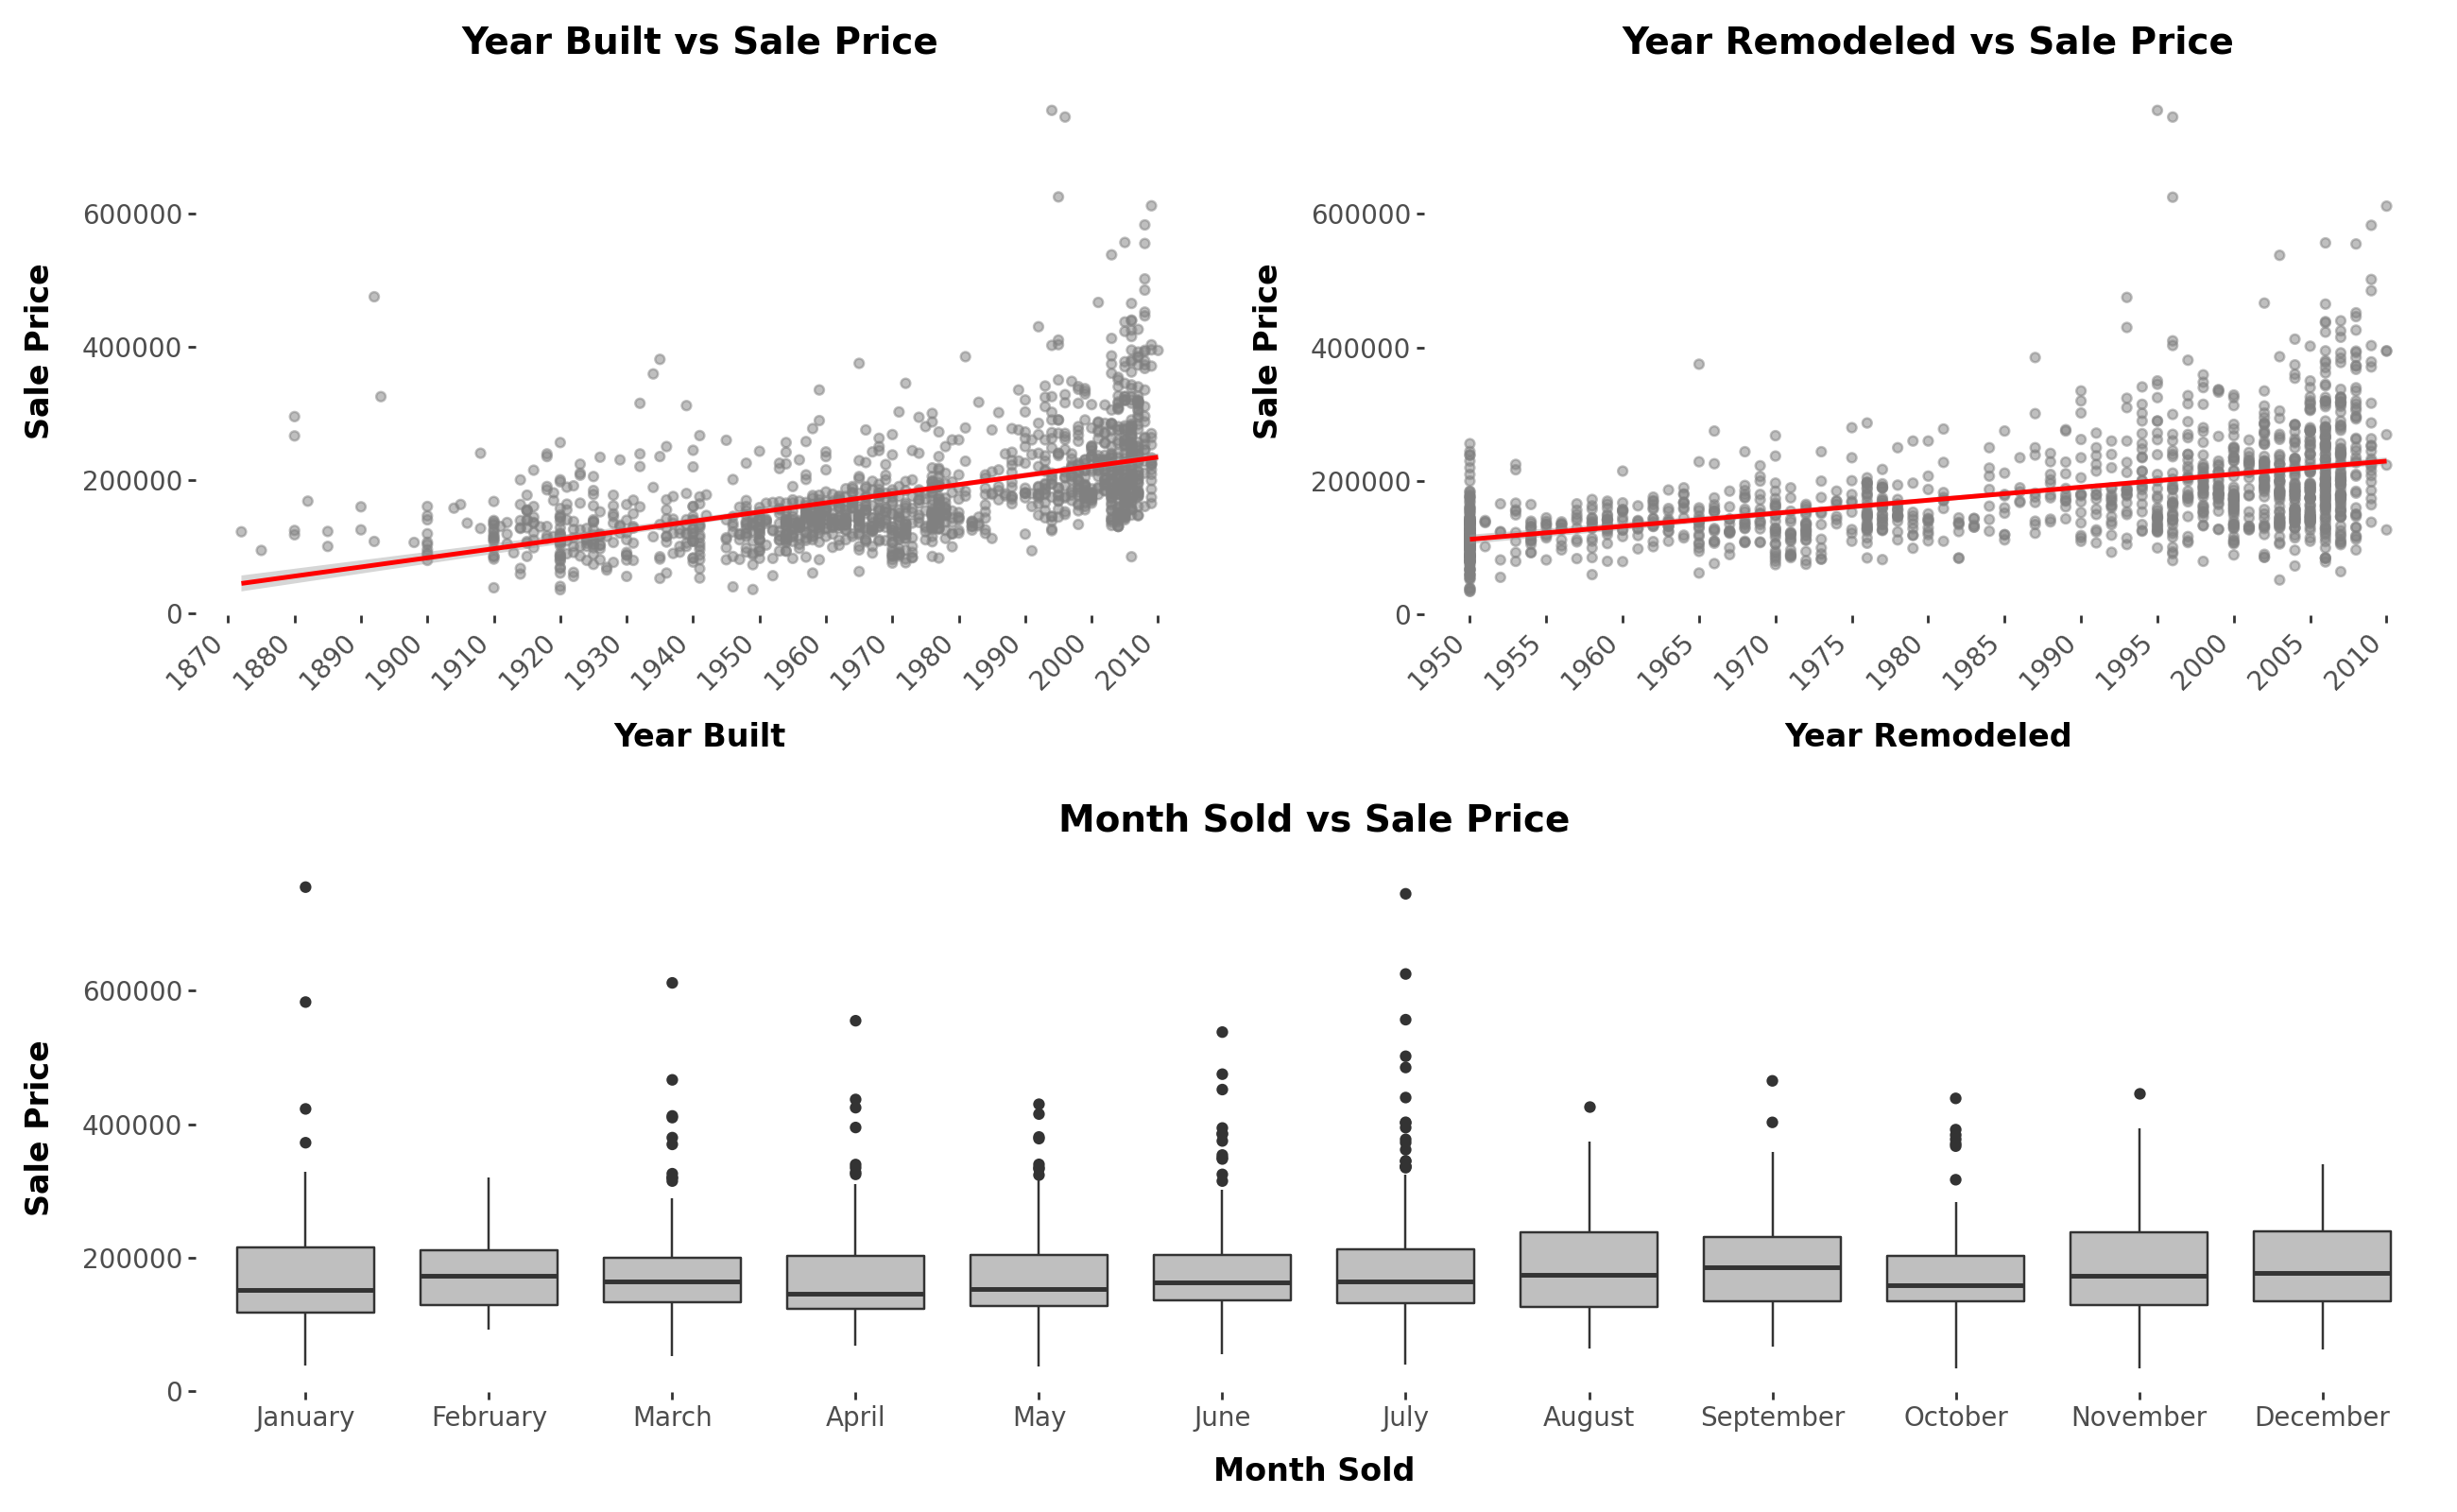

In [ ]:
year_built_scatter = ggplot(train_data, aes(x='YearBuilt', y='SalePrice')) + \
    geom_point(color='grey', alpha=0.5) + \
    geom_smooth(method='lm', color='red') + \
    report_theme + theme(figure_size=(10, 6), axis_text_x=element_text(angle=45, hjust=1)) + \
    scale_x_continuous(breaks=range(1870, 2011, 10)) + \
    labs(title='Year Built vs Sale Price', x='Year Built', y='Sale Price')

year_remod_scatter = ggplot(train_data, aes(x='YearRemodAdd', y='SalePrice')) + \
    geom_point(color='grey', alpha=0.5) + \
    geom_smooth(method='lm', color='red') + \
    report_theme + theme(figure_size=(10, 6), axis_text_x=element_text(angle=45, hjust=1)) + \
    scale_x_continuous(breaks=range(1950, 2011, 5)) + \
    labs(title='Year Remodeled vs Sale Price', x='Year Remodeled', y='Sale Price')

month_sold_box = ggplot(train_data, aes(x='factor(MoSold)', y='SalePrice')) + \
    geom_boxplot(fill='grey', alpha=0.5, ) + \
    report_theme + theme(figure_size=(10, 6)) + \
    scale_x_discrete(labels={1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}) + \
    labs(title='Month Sold vs Sale Price', x='Month Sold', y='Sale Price')  

(year_built_scatter | year_remod_scatter) / month_sold_box + theme(figure_size=(13, 8))

### Location & Property Type vs SalePrice

Finally, we will look at the relationship between the location and property type features (Neighborhood, MSZoning and BldgType) and the sale price of the houses.

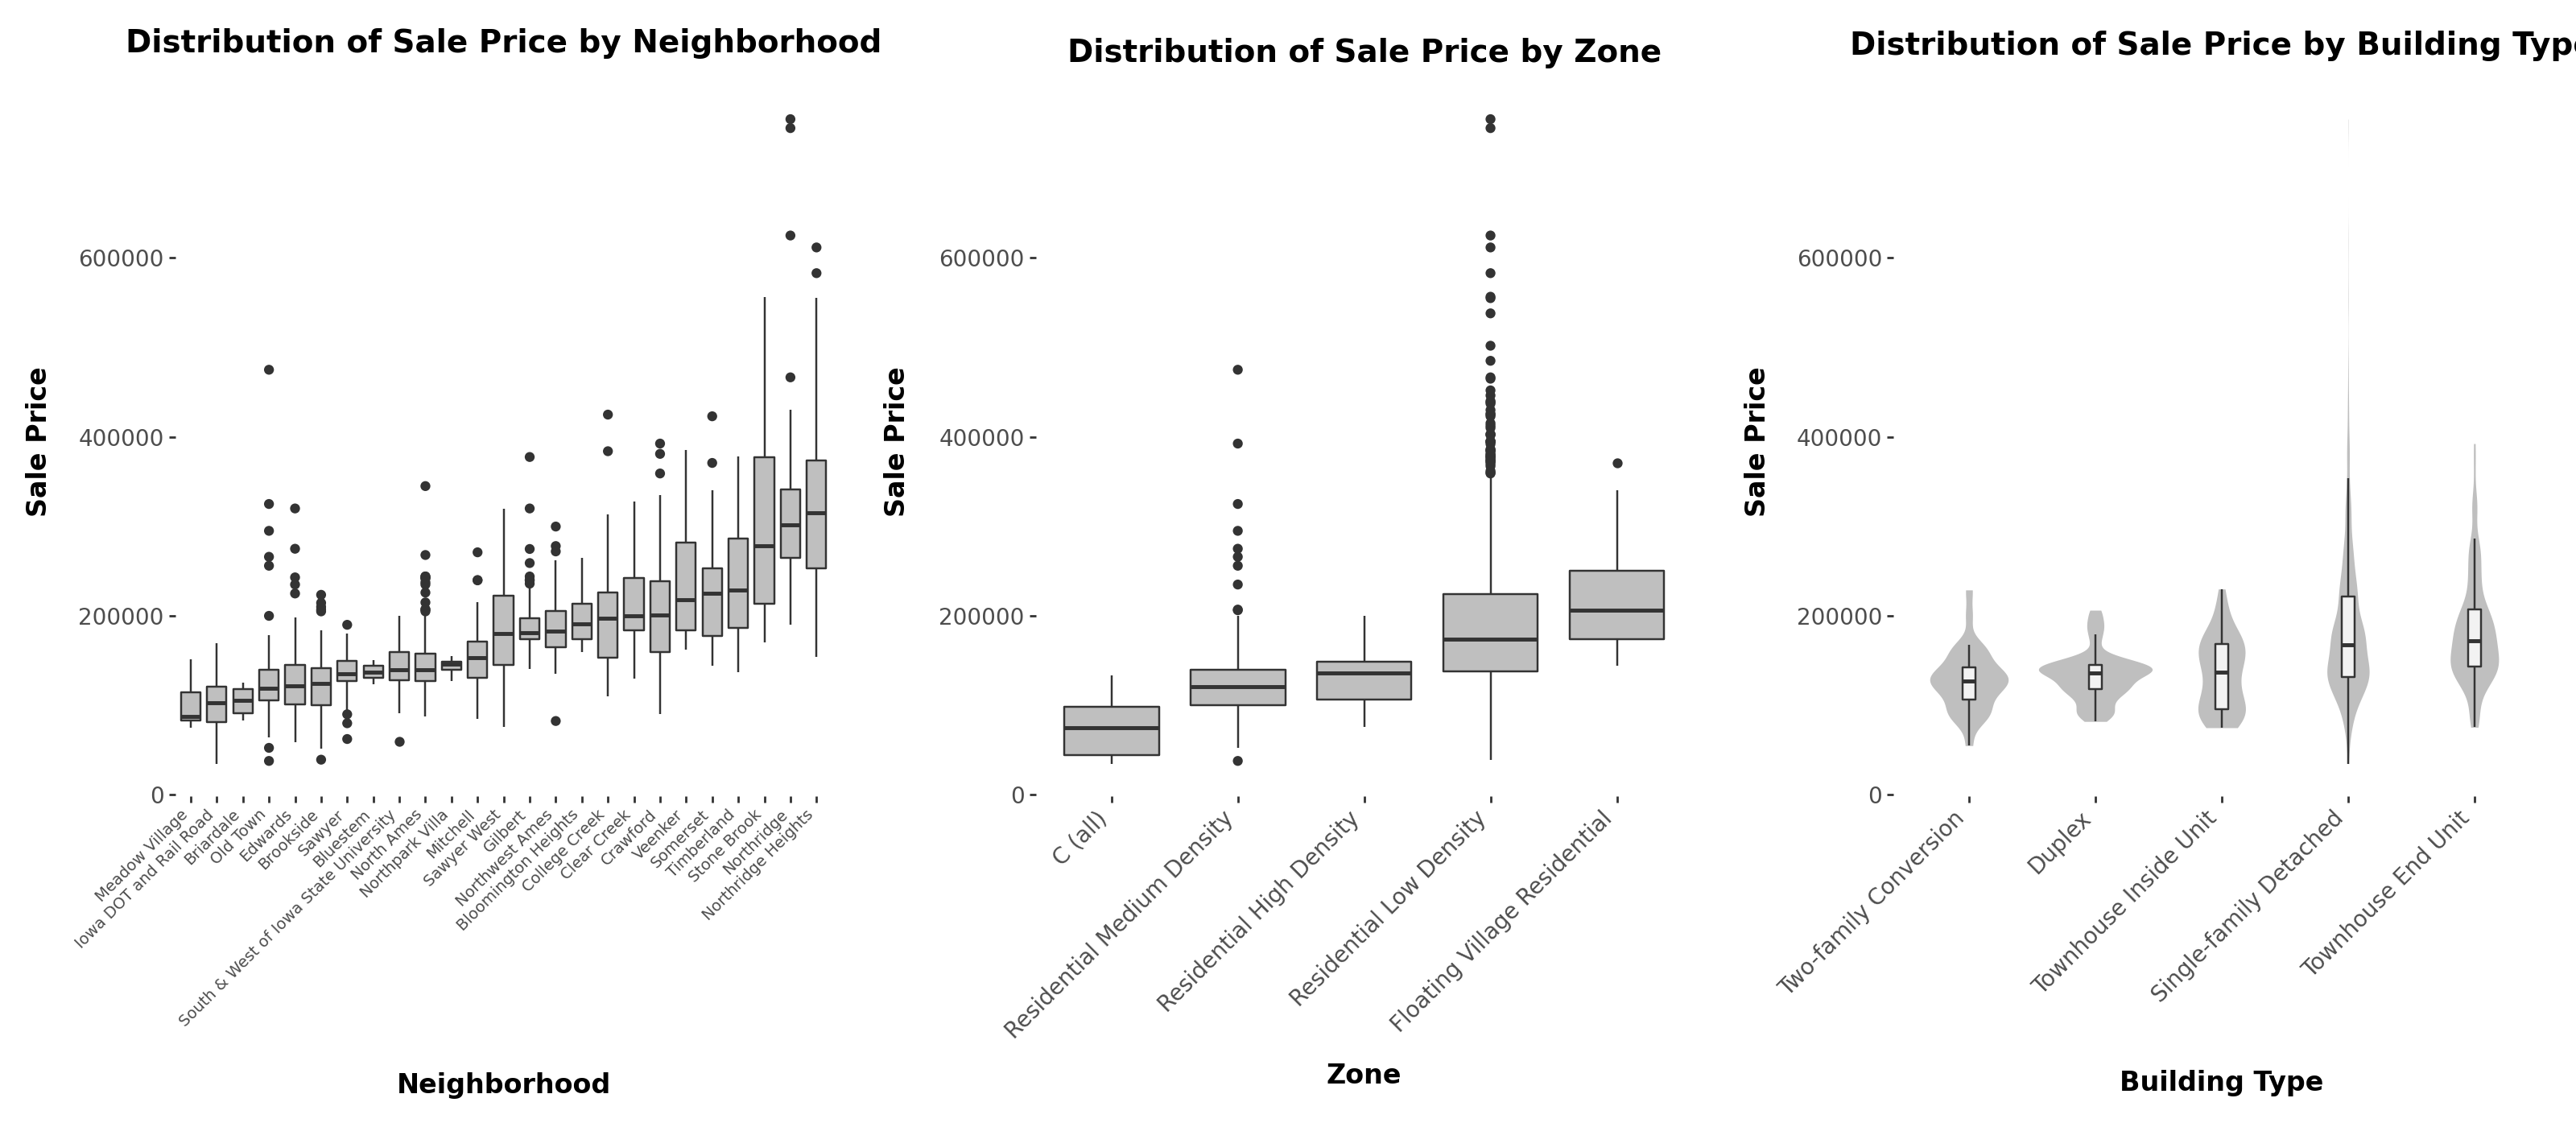

In [108]:
import numpy as np

neighborhood_box = ggplot(train_data, aes(x='reorder(Neighborhood, SalePrice, np.median)', y='SalePrice')) + \
    geom_boxplot(fill = 'grey', alpha = 0.5) + \
    scale_x_discrete(labels=neighborhood_labels) + \
    report_theme + theme(figure_size=(15, 6), axis_text_x=element_text(angle=45, hjust=1, size=7)) + \
    labs(title='Distribution of Sale Price by Neighborhood', x='Neighborhood', y='Sale Price')

mszoning_box = ggplot(train_data, aes(x='reorder(MSZoning, SalePrice, np.median)', y='SalePrice')) + \
    geom_boxplot(fill='grey', alpha=0.5) + \
    scale_x_discrete(labels=mszoning_mapping) + \
    report_theme + theme(figure_size=(10, 6), axis_text_x=element_text(angle=45, hjust=1)) + \
    labs(title='Distribution of Sale Price by Zone', x='Zone', y='Sale Price')

bldgtype_violin = ggplot(train_data, aes(x='reorder(BldgType, SalePrice, np.median)', y='SalePrice')) + \
    geom_violin(fill='grey', alpha=0.5, color='none') + \
    geom_boxplot(width=0.1, fill='white', alpha=0.8, outlier_shape='') + \
    scale_x_discrete(labels=bldgtype_mappings) + \
    report_theme + theme(figure_size=(10, 6), axis_text_x=element_text(angle=45, hjust=1)) + \
    labs(title='Distribution of Sale Price by Building Type', x='Building Type', y='Sale Price')

(neighborhood_box | mszoning_box | bldgtype_violin) + theme(figure_size=(16, 7))